In [10]:
import sys
import uproot
import ROOT as r
import numpy as np
import array as arr
import awkward as ak
import os
import matplotlib.pyplot as plt
#from analysis import Analysis
import logging
import pickle
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
os.environ['MEDULLA_PLOT_DIR'] =  '/nashome/m/micarrig/sbnd/nueCCNp/medulla/spineplot/'
sys.path.append('/nashome/m/micarrig/sbnd/nueCCNp/medulla/spineplot/')
from efficiency import SpineEfficiency
from analysis import Analysis
#from efficiency import SpineEfficiency

os.environ['BEARER_TOKEN_FILE'] = f"/tmp/bt_u{os.getuid()}_sbnd"

%jsroot on 

r.gStyle.SetOptStat(0)

print(os.environ['BEARER_TOKEN_FILE'])

/tmp/bt_u57240_sbnd


In [11]:
class selection():

    def __init__(self, name, label, operator='==', threshold=1, sel=None, nan_val=None):
        self.name = name
        self.label = label
        self.efficiency = -1.0
        self.purity = -1.0
        self.nu_efficiency = -1.0
        self.operator = operator  # '==', '!=', '<', '<=', '>', '>='
        self.threshold = threshold
        self.eff_den, self.eff_num = -1.0, -1.0
        self.pur_den, self.pur_num = -1.0, -1.0
        self.nu_eff_den, self.nu_eff_num = -1.0, -1.0
        self.sel = sel  # Optional custom selection function as a string
        self.nan_val = nan_val  # Value to replace NaNs with, if needed
    
    def apply_cut(self, branch_array):
        """Apply the cut based on operator and threshold"""
        if self.nan_val is not None:
            branch_array = np.where(np.isnan(branch_array), self.nan_val, branch_array)
        if self.sel is not None:
            print("Applying custom selection function:", self.sel, branch_array)
            branch_array = eval(self.sel)
            print("applied new branch", self.sel, branch_array)
            
        if self.operator == '==':
            return branch_array == self.threshold
        elif self.operator == '!=':
            return branch_array != self.threshold
        elif self.operator == '<':
            return branch_array < self.threshold
        elif self.operator == '<=':
            return branch_array <= self.threshold
        elif self.operator == '>':
            return branch_array > self.threshold
        elif self.operator == '>=':
            return branch_array >= self.threshold
        else:
            raise ValueError(f"Unknown operator: {self.operator}")

def print_selection_stats(selection_list):
    """Print name and efficiency/purity for each selection."""
    if not selection_list:
        print("No selections provided.")
        return

    headers = ("Selection", "Slice/Int Efficiency", "Neutrino Efficiency", "Purity")
    rows = []

    for sel in selection_list:
        eff_str = "N/A" if sel.efficiency == -1 else f"{sel.efficiency:.4f} ({sel.eff_num}/{sel.eff_den})"
        eff_nu_str = "N/A" if sel.nu_efficiency == -1 else f"{sel.nu_efficiency:.4f} ({sel.nu_eff_num}/{sel.nu_eff_den})"
        pur_str = "N/A" if sel.purity == -1 else f"{sel.purity:.4f} ({sel.pur_num}/{sel.pur_den})"
        rows.append((str(sel.label), eff_str, eff_nu_str, pur_str))

    sel_w = max([len(headers[0])] + [len(r[0]) for r in rows])
    w1 = max([len(headers[1])] + [len(r[1]) for r in rows])
    w2 = max([len(headers[2])] + [len(r[2]) for r in rows])
    w3 = max([len(headers[3])] + [len(r[3]) for r in rows])

    header_fmt = f"{{:<{sel_w}}}  {{:^{w1}}}  {{:^{w2}}}  {{:^{w3}}}"
    row_fmt = f"{{:<{sel_w}}}  {{:>{w1}}}  {{:>{w2}}}  {{:>{w3}}}"
    total_w = sel_w + w1 + w2 + w3 + 6

    print("\nSelection Summary")
    print(header_fmt.format(*headers))
    print("-" * total_w)
    for row in rows:
        print(row_fmt.format(*row))
    print("-" * total_w)

In [12]:
colors = [r.kBlack, r.kRed, r.kBlue, r.kGreen+2, r.kMagenta, r.kCyan+2, r.kOrange+7, r.kViolet+7, r.kAzure+7, r.kPink+7, r.kYellow+7]

def get_varHists(var, tree, bins=50, xmin=0, xmax=5):
    fullSel = ak.ones_like(tree[var].array(), dtype=bool)
    histograms = {}
    
    h = r.TH1F("h", "h", bins, xmin, xmax)

    data_array = tree[var].array()
    data_cleaned = ak.drop_none(ak.nan_to_none(ak.flatten(data_array, -1)), axis=None)

    eff_var = 'true_category'
    signal_index = 0  # Assuming category 0 is the signal
    true_nu = tree[eff_var].array()
    true_nu_flat = ak.drop_none(ak.nan_to_none(ak.flatten(tree[eff_var].array(), -1)), axis=None)

    total_entries = len(true_nu_flat[true_nu_flat == signal_index])
    for sel in selections:
        print(f"Applying selection: {sel.label}")
        # Use the apply_cut method instead of hardcoded == 1
        fullSel = fullSel & sel.apply_cut(tree[sel.name].array())
        h = r.TH1F("h", "h", bins, xmin, xmax)
        array_ = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[fullSel], -1)), axis=None)
        entries_ = ak.drop_none(ak.nan_to_none(ak.flatten(true_nu[fullSel], -1)), axis=None)
        entriesSel_ = len(entries_)
        entries_ = len(entries_[entries_ == signal_index])
        if sel.efficiency == -1: sel.efficiency = entries_/total_entries
        if sel.purity == -1: sel.purity = entries_/entriesSel_ if entriesSel_ > 0 else 0
        print(f"Efficiency after {sel.label}: {sel.efficiency:.4f} ({entries_}/{total_entries})")
        if len(array_) > 0:
            h.FillN(len(array_), arr.array('d', array_), np.ones(len(array_)))
        histograms[sel.label] = h
    
    return histograms

def plot_hists(histograms, selections, title, titleX, titleY, range=None):
    c1 = r.TCanvas("c1", "c1", 800, 600)

    l = r.TLegend(0.6,0.6,0.88,0.88) 

    maxY = max(hist.GetMaximum() for hist in histograms.values())               

    for ih, (key, hist) in enumerate(histograms.items()):
        hist.SetLineWidth(2)
        hist.SetLineColor(colors[ih % len(colors)])
        hist.SetTitle(f"{title}: {key}; {titleX}; {titleY}")

        if ih ==0 : 
            if range is not None:
                hist.GetYaxis().SetRangeUser(range[0], range[1])
            else:
                hist.GetYaxis().SetRangeUser(1, maxY*1.2)
            hist.Draw("")
        else: hist.Draw("SAME")

        l.AddEntry(hist, f'{key}, e={selections[ih].efficiency:.2f}, p={selections[ih].purity:.2f}', "l")

    l.Draw()
    c1.SetLogy()
    return c1, l

def get_effHists(var, tree, selections, total=None, bins=50, xmin=0, xmax=5, eff_var='true_category', nu_eff_var=None,signal_index=0, scale=1):

    histograms = {}

    data_array = tree[var].array() * scale
    data_cleaned = ak.drop_none(ak.nan_to_none(ak.flatten(data_array, -1)), axis=None)

    if isinstance(eff_var, np.ndarray):
        print("Using provided efficiency variable array")
        true_nu = eff_var
        true_nu_flat = ak.drop_none(ak.nan_to_none(ak.flatten(true_nu, -1)), axis=None)
        fullSel = ak.ones_like(eff_var, dtype=bool)

    else:
        true_nu = tree[eff_var].array()
        true_nu_flat = ak.drop_none(ak.nan_to_none(ak.flatten(tree[eff_var].array(), -1)), axis=None)
        fullSel = ak.ones_like(true_nu, dtype=bool)
        
    fullSel = np.where(np.isnan(true_nu), False, fullSel)  # Ensure no NaNs in the selection mask
    print("Unique values in efficiency variable:", np.unique(true_nu_flat))

    total_entries = len(true_nu_flat[true_nu_flat == signal_index])
    
    # Create denominator histogram once with only signal events
    signal_mask = true_nu == signal_index
    total_signal_array = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[signal_mask], -1)), axis=None)
    
    for sel in selections:
        print(f"Applying selection: {sel.label}")
        # Use the apply_cut method instead of hardcoded == 1
        fullSel = fullSel & sel.apply_cut(tree[sel.name].array())

        if isinstance(bins, arr.array):
            h_num = r.TH1F("h_num", "h_num", len(bins)-1, bins)
            h_den = r.TH1F("h_den", "h_den", len(bins)-1, bins)
        else:
            h_num = r.TH1F("h_num", "h_num", bins, xmin, xmax)
            h_den = r.TH1F("h_den", "h_den", bins, xmin, xmax)
        g_ratio = r.TGraphAsymmErrors()
        
        # Numerator: selected events that are signal
        combined_mask = fullSel & signal_mask
        array_ = ak.drop_none(ak.nan_to_none(ak.flatten(data_array[combined_mask], -1)), axis=None)
        
        print(f"total entries in selection: {len(ak.flatten(true_nu[fullSel], -1))}")
        entries_ = ak.drop_none(ak.nan_to_none(ak.flatten(true_nu[fullSel], -1)), axis=None)
        entriesSel_ = len(entries_)
        print(f"Selected entries: {entriesSel_}")
        entries_ = len(entries_[entries_ == signal_index])
        print(f"Purity: {entries_}/{entriesSel_} = {entries_/entriesSel_ if entriesSel_ > 0 else 0:.4f}")
        if sel.efficiency == -1: 
            sel.efficiency = entries_/total_entries if total_entries > 0 else 0
            sel.eff_den = total_entries
            sel.eff_num = entries_
        if sel.purity == -1: 
            sel.purity = entries_/entriesSel_ if entriesSel_ > 0 else 0
            sel.pur_den = entriesSel_
            sel.pur_num = entries_
        if total is not None and sel.nu_efficiency == -1: 
            if nu_eff_var is not None:
                nu_eff_num = ak.nan_to_none(ak.flatten(tree[nu_eff_var].array()[fullSel], -1))
                none_mask = ~ak.is_none(nu_eff_num)
                true_nu_sel = ak.nan_to_none(ak.flatten(true_nu[fullSel], -1)[none_mask] == signal_index)
                nu_eff_num = nu_eff_num[none_mask]
                print(len(nu_eff_num), len(true_nu_sel))
                nu_eff_num = len(np.unique(ak.to_numpy(nu_eff_num[true_nu_sel])))
            else:
                nu_eff_num = entries_
            sel.nu_efficiency = nu_eff_num/total if total > 0 else 0
            sel.nu_eff_den = total
            sel.nu_eff_num = nu_eff_num
        print(f"Efficiency after {sel.label}: {sel.efficiency:.4f} ({entries_}/{total_entries})")
        
        # Fill numerator with selected signal events
        if len(array_) > 0:
            h_num.FillN(len(array_), arr.array('d', array_), np.ones(len(array_)))
        
        # Fill denominator with all signal events (denominator is constant)
        if len(total_signal_array) > 0:
            h_den.FillN(len(total_signal_array), arr.array('d', total_signal_array), np.ones(len(total_signal_array)))

        g_ratio = r.TGraphAsymmErrors(h_num, h_den)
        
        histograms[sel.label] = g_ratio
    
    return histograms

def plot_hist(vals, bins, labels, colors, truth_category, title, counts=False, POT=None):

    centers = (bins[:-1] + bins[1:]) / 2

    fig, ax = plt.subplots(
        2, 1,
        figsize=(10, 8),
        gridspec_kw={"height_ratios": [3, 1]})

    l_vals = []
    for cat in labels.keys():
        cat_mask = truth_category == cat
        l_vals.append(vals[cat_mask])

    purities = [len(x)/len(truth_category) for x in l_vals]

    if counts:
        labels = {i: f"{labels[i]} p={purities[i]:.2f}({len(l_vals[i])}/{len(truth_category)})" for i in labels.keys()}
    else:
        labels = {i: f"{labels[i]} (p={purities[i]:.2f})" for i in labels.keys()}

    ax[0].hist(l_vals[::-1], bins=bins, label=list(labels.values())[::-1], stacked=True, color=colors[::-1])
    ax[0].set_ylabel('Interactions')
    ax[0].tick_params(top=True, right=True, direction="in")
    ax[0].grid(True, which="both", linestyle="--", alpha=0.5)

    # Plot stamps in the top margin to avoid overlapping the legend/histogram
    ax[0].text(
        0.0, 1.02,
        "SBND preliminary",
        transform=ax[0].transAxes,
        ha="left", va="bottom",
        fontsize=12, fontweight="bold",
        clip_on=False,
    )
    if POT is not None:
        if isinstance(POT, (int, float, np.number)):
            pot_str = f"{float(POT):.3g}"
        else:
            pot_str = str(POT)
        ax[0].text(
            1.0, 1.02,
            f"POT = {pot_str}",
            transform=ax[0].transAxes,
            ha="right", va="bottom",
            fontsize=12,
            clip_on=False,
        )

    ax[0].legend()

    signal_vals = [v[np.isfinite(v)] for v in l_vals[:2] if len(v) > 0]
    signal_vals = np.concatenate(signal_vals) if signal_vals else np.array([])
    signal_hist, _ = np.histogram(l_vals[0], bins=bins)
    
    background_vals = [v[np.isfinite(v)] for v in l_vals[2:] if len(v) > 0]
    background_vals = np.concatenate(background_vals) if background_vals else np.array([])
    sel_hist, _ = np.histogram(background_vals, bins=bins)

    ratio = np.divide(
        signal_hist,
        sel_hist,
        out=np.zeros_like(sel_hist, dtype=float),
        where=sel_hist > 0,
    )
    ratio_err = np.sqrt(
        np.divide(
            ratio * (1 - ratio),
            sel_hist,
            out=np.zeros_like(ratio, dtype=float),
            where=sel_hist > 0,
        )
    )

    ax[1].errorbar(centers, ratio, yerr=ratio_err, fmt="o", color="gray", capsize=3)
    ax[1].set_xlabel(title)
    ax[1].set_ylabel("S/B")

    return ax, fig

In [54]:
# fall = uproot.open("/nashome/m/micarrig/sbnd/nueCCNp/output_nueCCNp.root:events/signal/all") #1e18 sample
# fsel = uproot.open("/nashome/m/micarrig/sbnd/nueCCNp/output_nueCCNp.root:events/signal/true_signal")

fall = uproot.open("root://fndcadoor.fnal.gov:/sbnd/scratch/users/micarrig/nueCCNp_v2/output/merged_output.root:events/signal/all")
fsel = uproot.open("root://fndcadoor.fnal.gov:/sbnd/scratch/users/micarrig/nueCCNp_v2/output/merged_output.root:events/signal/true_signal")

vals, edges = uproot.open("root://fndcadoor.fnal.gov:/sbnd/scratch/users/micarrig/nueCCNp_v2/output/merged_output.root:events/signal/POT").to_numpy()
totalPOT = vals[0] if len(vals) > 0 else None

fall = uproot.open("/nashome/m/micarrig/sbnd/nueCCNp/output_nueCCNp_v2.root:events/signal/all") #debug sample
fsel = uproot.open("/nashome/m/micarrig/sbnd/nueCCNp/output_nueCCNp_v2.root:events/signal/true_signal")

In [ ]:
fall.keys()

['reco_containment_cut',
 'reco_cut_type',
 'reco_dalphaT',
 'reco_dpL',
 'reco_dpL_lp',
 'reco_dpT',
 'reco_dpT_lp',
 'reco_dphiT',
 'reco_ele_beam_open_angle',
 'reco_electron_multiplicity',
 'reco_electron_softmax_cut',
 'reco_fiducial_cut',
 'reco_flash_cut',
 'reco_flash_time',
 'reco_has_electron',
 'reco_has_proton',
 'reco_is_data',
 'reco_is_nu',
 'reco_leading_ele_energy_cut',
 'reco_leading_electron_axial_cut',
 'reco_leading_electron_axial_spread',
 'reco_leading_electron_azimuthal_angle',
 'reco_leading_electron_calo_ke',
 'reco_leading_electron_containment_cut',
 'reco_leading_electron_csda_ke',
 'reco_leading_electron_directional_spread',
 'reco_leading_electron_electron_softmax',
 'reco_leading_electron_end_dir_x',
 'reco_leading_electron_end_dir_y',
 'reco_leading_electron_end_dir_z',
 'reco_leading_electron_end_x',
 'reco_leading_electron_end_y',
 'reco_leading_electron_end_z',
 'reco_leading_electron_energy',
 'reco_leading_electron_ke',
 'reco_leading_electron_lengt

### Breakdown of signal vs backgrounds

In [14]:
selections = []
selections.append(selection("reco_no_cut", "No Cut"))
selections.append(selection("reco_fiducial_cut", "Fiducial Cut", operator='==', threshold=1, nan_val=0))
# selections.append(selection("reco_flash_cut", "Flash Cut", operator='==', threshold=1, nan_val=-999))
selections.append(selection("reco_valid_flashmatch", "Valid Flash Match", operator='==', threshold=1, nan_val=-999))
selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
# selections.append(selection("reco_has_electron", ">=1 Electron-like Particle"))
# selections.append(selection("reco_no_muons", "0 Muon-like Particles", operator='==', threshold=1))
selections.append(selection("reco_leading_muon_p", "0 Muon-like Particles", operator='==', threshold=1, nan_val=-1, sel="np.where((branch_array < 25), 1, 0)"))
# selections.append(selection("reco_no_charged_pions", "0 Charged Pion-like Particles", operator='==', threshold=1))
selections.append(selection("reco_leading_pion_p", "0 Charged Pion-like Particles", operator='==', threshold=1, nan_val=-1, sel="np.where((branch_array < 25), 1, 0)"))
# selections.append(selection("reco_has_proton", ">=1 Proton-like Particle"))
selections.append(selection("reco_leading_proton_p", "Leading Proton Momentum > 40 MeV", operator='>', threshold=40, nan_val=-999))
selections.append(selection("reco_leading_electron_electron_softmax", "Leading Electron Softmax > 0.90", operator='>', threshold=0.90))
selections.append(selection("reco_leading_electron_primary_softmax", "Leading Electron Primary Softmax > 0.99", operator='>', threshold=0.99))
selections.append(selection("reco_leading_proton_proton_softmax", "Leading Proton Softmax > 0.75", operator='>', threshold=0.75))
# selections.append(selection("reco_leading_electron_axial_spread", "Leading Electron Axial Spread > 0.1", operator='>', threshold=0.1))
# selections.append(selection("reco_leading_photon_energy", "Leading Photon Energy < 150 MeV", operator='==', threshold=1, sel="np.where((branch_array < 150), 1, 0)", nan_val=-999))
selections.append(selection("reco_leading_electron_p", "Leading Electron Momentum > 75 MeV", operator='>', threshold=75))
selections.append(selection("reco_leading_electron_vertex_distance", "Leading Electron Vertex Distance < 3.5 cm", operator='<', threshold=3.5))
selections.append(selection("reco_leading_electron_start_dedx", "Leading Electron dEdx < 4 MeV/cm", operator='<', threshold=4))


true_selections = []
true_selections.append(selection("true_fiducial_cut", "True Fiducial Cut"))
true_selections.append(selection("true_has_electron", "True Has Electron"))
true_selections.append(selection("true_has_proton", "True Has Proton"))
true_selections.append(selection("true_no_muons", "True No Muons"))
true_selections.append(selection("true_no_charged_pions", "True No Charged Pions"))
true_selections.append(selection("true_containment_cut", "True Containment Cut"))

In [15]:
true_category = fall['true_category'].array(library="np")
true_category_truth = fsel['true_category'].array(library="np")

sel_mask = np.ones_like(true_category, dtype=bool)
sel_mask = np.where(np.isnan(true_category), False, sel_mask)  # Exclude NaN values from the mask
for sel in selections:
    print(f"Applying selection: {sel.label}")
    this_mask = sel.apply_cut(fall[sel.name].array(library="np"))
    sel_mask &= this_mask

# sel_mask_truth = np.ones_like(true_category_truth, dtype=bool)
# sel_mask_truth = np.where(np.isnan(true_category_truth), False, sel_mask_truth)  # Exclude NaN values from the mask
# for sel in selections:
#     this_mask = sel.apply_cut(fsel[sel.name].array(library="np"))
#     sel_mask_truth &= this_mask

# true_mask = np.ones_like(true_category, dtype=bool)
# for sel in true_selections:
#     this_mask = sel.apply_cut(fall[sel.name].array(library="np"))
#     true_mask &= this_mask

true_category_sel = true_category[sel_mask]
# true_category_sel_truth = true_category_truth[sel_mask_truth]


Applying selection: No Cut
Applying selection: Fiducial Cut
Applying selection: Valid Flash Match
Applying selection: Interaction Containment Cut
Applying selection: 0 Muon-like Particles
Applying custom selection function: np.where((branch_array < 25), 1, 0) [ 7.77821045e+02  1.27143408e+03 -1.00000000e+00 ...  7.34801086e+02
  6.20544189e+02  1.00547607e+03]
applied new branch np.where((branch_array < 25), 1, 0) [0 0 1 ... 0 0 0]
Applying selection: 0 Charged Pion-like Particles
Applying custom selection function: np.where((branch_array < 25), 1, 0) [-1. -1. -1. ... -1. -1. -1.]
applied new branch np.where((branch_array < 25), 1, 0) [1 1 1 ... 1 1 1]
Applying selection: Leading Proton Momentum > 40 MeV
Applying selection: Leading Electron Softmax > 0.90
Applying selection: Leading Electron Primary Softmax > 0.99
Applying selection: Leading Proton Softmax > 0.75
Applying selection: Leading Electron Momentum > 75 MeV
Applying selection: Leading Electron Vertex Distance < 3.5 cm
Applyin

In [16]:
# labels = {0: 'Signal', 1: r'$\nu_{e}$ CC Other', 2: r'$\nu_{\mu}$', 3: 'OOFV', 4: 'NC', 5: 'Cosmic'}
# category_colors = ['#001261', '#1E6F9D', '#EACEBD', '#BE6533','#8B2706', '#590008']

labels = {0: 'Signal Np', 1: 'Signal 1p', 2: 'OOFV', 3: 'OOPS', 4: r'$\nu_{e}N\pi^{\pm}$', 5: r'$\nu_eN\mu$', 6: r'$\nu_{e}$ Other', 7: r'$\nu_{\mu}$', 8: 'NC', 9: 'Cosmic', 10: 'Other'}
category_colors = ['#001261', '#033E7D', '#1E6F9D', '#71A8C4', '#C9DDE7', '#EACEBD', '#D39774', '#BE6533', '#8B2706', '#590008', '#000000'] #vik


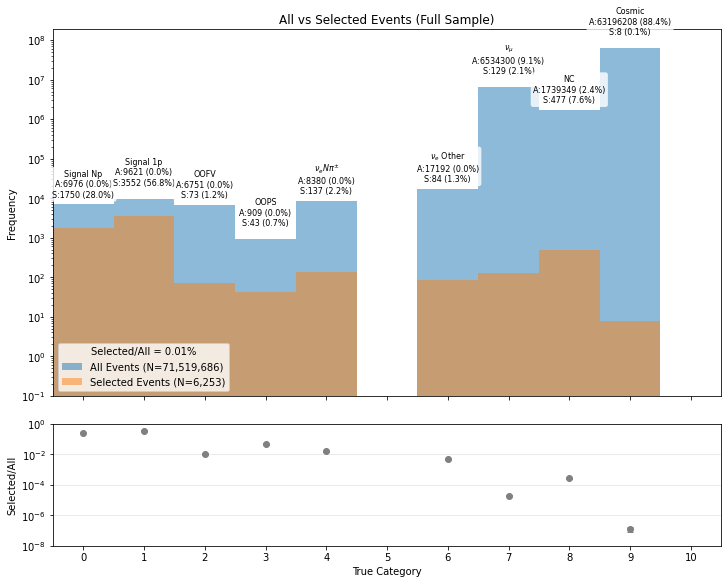

In [51]:
# One panel (Full Sample): All vs Selected categories, with (hist, ratio) stacked.

cat_bins = np.arange(-0.5, 11.5, 1)
centers = (cat_bins[:-1] + cat_bins[1:]) / 2

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    constrained_layout=True,
)

ax_hist = axes[0]
ax_ratio = axes[1]

# All events categories
categories_all = np.asarray(true_category)

# Selected categories derived on-the-fly (so this cell doesn't require true_category_sel)
if "sel_mask" in globals():
    categories_sel = np.asarray(true_category)[sel_mask]
else:
    categories_sel = None

all_hist, _ = np.histogram(categories_all, bins=cat_bins)
all_total = int(all_hist.sum())

if categories_sel is not None:
    sel_hist, _ = np.histogram(categories_sel, bins=cat_bins)
    sel_total = int(sel_hist.sum())
    overall_frac = (sel_total / all_total) if all_total > 0 else 0.0
else:
    sel_hist = np.zeros_like(all_hist)
    sel_total = 0
    overall_frac = 0.0

# Plot with totals embedded in legend labels (avoids duplicate text boxes).
ax_hist.hist(
    categories_all,
    bins=cat_bins,
    label=f"All Events (N={all_total:,})",
    alpha=0.5,
)
if categories_sel is not None:
    ax_hist.hist(
        categories_sel,
        bins=cat_bins,
        label=f"Selected Events (N={sel_total:,})",
        alpha=0.5,
    )

ax_hist.set_ylabel("Frequency")
ax_hist.set_title("All vs Selected Events (Full Sample)")
ax_hist.set_yscale("log")

ymax = max(all_hist.max(), sel_hist.max())
ax_hist.set_ylim(0.1, ymax * 3.0 if ymax > 0 else 1.0)

legend_title = f"Selected/All = {overall_frac:.2%}" if categories_sel is not None else "No selection mask"
ax_hist.legend(title=legend_title, loc="lower left")

# Annotate each category bin with counts + fraction of total events.
# - All fraction is relative to All total
# - Selected fraction is relative to Selected total
for i in range(len(all_hist)):
    a = int(all_hist[i])
    s = int(sel_hist[i])
    if a <= 0 and s <= 0:
        continue
    label = labels.get(i, str(i))

    a_frac = (a / all_total) if all_total > 0 else 0.0
    s_frac = (s / sel_total) if sel_total > 0 else 0.0

    # Stagger text to reduce collisions between neighboring bins on log scale
    y = max(a, s) * (1.35 if (i % 2 == 0) else 1.95)

    ax_hist.text(
        i, y,
        f"{label}\nA:{a} ({a_frac:.1%})\nS:{s} ({s_frac:.1%})",
        ha="center", va="bottom", fontsize=8,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.80, edgecolor="none"),
        clip_on=False,
    )

if categories_sel is not None:
    ratio = np.divide(
        sel_hist,
        all_hist,
        out=np.zeros_like(sel_hist, dtype=float),
        where=all_hist > 0,
    )
    ratio_err = np.sqrt(
        np.divide(
            ratio * (1 - ratio),
            all_hist,
            out=np.zeros_like(ratio, dtype=float),
            where=all_hist > 0,
        )
    )

    ax_ratio.errorbar(centers, ratio, yerr=ratio_err, fmt="o", color="gray", capsize=3)
    ax_ratio.set_ylabel("Selected/All")
    ax_ratio.set_yscale("log")
    ax_ratio.set_ylim(1e-8, 1.05)
    ax_ratio.grid(axis="y", alpha=0.3)
else:
    ax_ratio.text(0.5, 0.5, "No selection mask", ha="center", va="center", transform=ax_ratio.transAxes)
    ax_ratio.set_yticks([])
    ax_ratio.grid(False)

ax_ratio.set_xlabel("True Category")
ax_ratio.set_xticks(centers)
ax_ratio.set_xlim(cat_bins[0], cat_bins[-1])

plt.show()


/tmp/ipykernel_12860/2156266731.py:39: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(
/tmp/ipykernel_12860/2156266731.py:70: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


Text(0, 0.5, 'S/B')

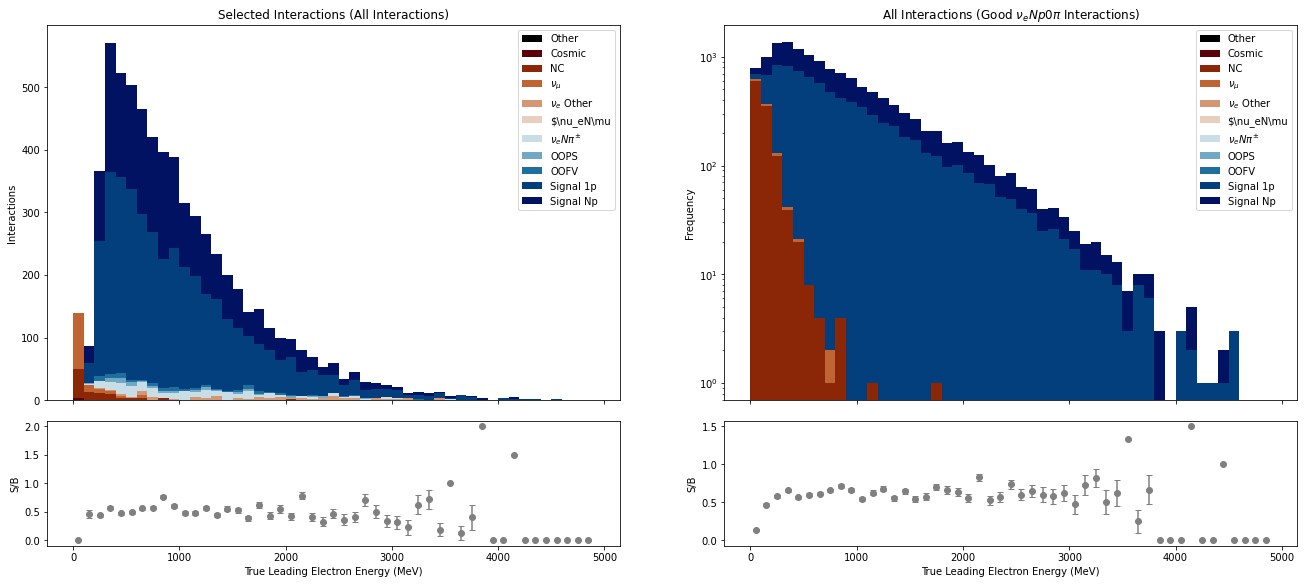

In [27]:
true_leading_electron_energy = fall['true_leading_electron_energy'].array(library="np")
true_leading_electron_energy_truth = fsel['true_leading_electron_energy'].array(library="np")

bins = np.arange(0, 5000, 100)
centers = (bins[:-1] + bins[1:]) / 2

fig, ax = plt.subplots(
    2, 2,
    figsize=(18, 8),
    sharex='col',
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05, "wspace": 0.1},
    constrained_layout=True)

vals = []
vals_sel = []
for cat in labels.keys():
    cat_mask = true_category == cat
    cat_mask_truth = true_category_truth == cat
    vals.append(true_leading_electron_energy_truth[cat_mask_truth])
    vals_sel.append(true_leading_electron_energy[cat_mask & sel_mask])

ax[0, 0].hist(vals_sel[::-1], bins=bins, label=list(labels.values())[::-1], stacked=True, color=category_colors[::-1])
ax[0, 0].set_ylabel('Interactions')
ax[0, 0].set_title('Selected Interactions (All Interactions)')
ax[0, 0].legend()

signal_hist, _ = np.histogram(vals_sel[0], bins=bins)
background_vals = [v[np.isfinite(v)] for v in vals_sel[1:] if len(v) > 0]
background_vals = np.concatenate(background_vals) if background_vals else np.array([])

sel_hist, _ = np.histogram(background_vals, bins=bins)

ratio = np.divide(
    signal_hist,
    sel_hist,
    out=np.zeros_like(sel_hist, dtype=float),
    where=sel_hist > 0,
)
ratio_err = np.sqrt(
    np.divide(
        ratio * (1 - ratio),
        sel_hist,
        out=np.zeros_like(ratio, dtype=float),
        where=sel_hist > 0,
    )
)

ax[1, 0].errorbar(centers, ratio, yerr=ratio_err, fmt="o", color="gray", capsize=3)
ax[1, 0].set_xlabel("True Leading Electron Energy (MeV)")
ax[1, 0].set_ylabel("S/B")

ax[0, 1].hist(vals[::-1], bins=bins, label=list(labels.values())[::-1], stacked=True, color=category_colors[::-1])
ax[0, 1].set_ylabel('Frequency')
ax[0, 1].set_title(r'All Interactions (Good $\nu_{e}Np0\pi$ Interactions)')
ax[0, 1].legend()
ax[0, 1].set_yscale('log')

signal_hist, _ = np.histogram(vals[0], bins=bins)
background_vals = [v[np.isfinite(v)] for v in vals[1:] if len(v) > 0]
background_vals = np.concatenate(background_vals) if background_vals else np.array([])

sel_hist, _ = np.histogram(background_vals, bins=bins)

ratio = np.divide(
    signal_hist,
    sel_hist,
    out=np.zeros_like(sel_hist, dtype=float),
    where=sel_hist > 0,
)
ratio_err = np.sqrt(
    np.divide(
        ratio * (1 - ratio),
        sel_hist,
        out=np.zeros_like(ratio, dtype=float),
        where=sel_hist > 0,
    )
)

ax[1, 1].errorbar(centers, ratio, yerr=ratio_err, fmt="o", color="gray", capsize=3)
ax[1, 1].set_xlabel("True Leading Electron Energy (MeV)")
ax[1, 1].set_ylabel("S/B")

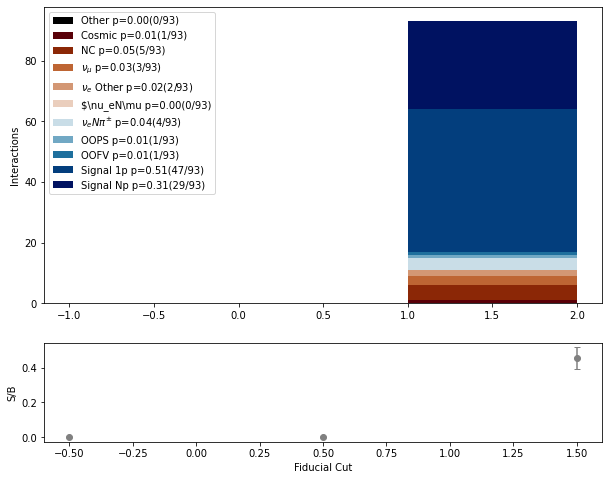

In [ ]:
fiducial_cut = fall['reco_fiducial_cut'].array(library="np")
# fiducial_cut = np.nan_to_num(fiducial_cut, nan=-0.5)
fiducial_cut_sel = fiducial_cut[sel_mask]

ax, fig = plot_hist(
    vals=fiducial_cut_sel,
    bins=np.arange(-1, 3, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Fiducial Cut",
    counts=True
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


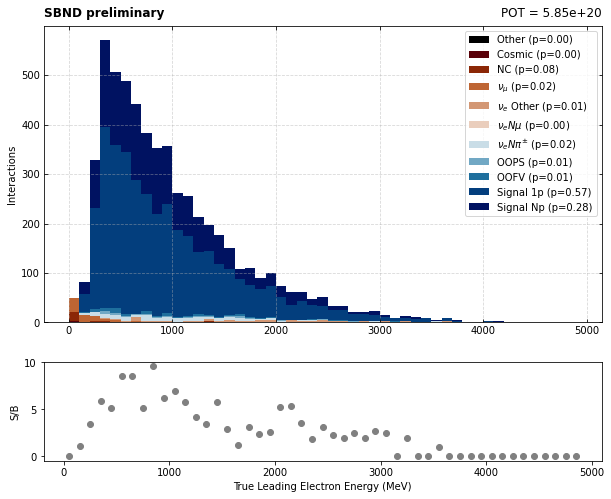

In [ ]:
true_leading_electron_energy = fall['true_leading_electron_energy'].array(library="np")
true_leading_electron_energy_sel = true_leading_electron_energy[sel_mask]

ax, fig = plot_hist(
    vals=true_leading_electron_energy_sel,
    bins=np.arange(0, 5000, 100),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="True Leading Electron Energy (MeV)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


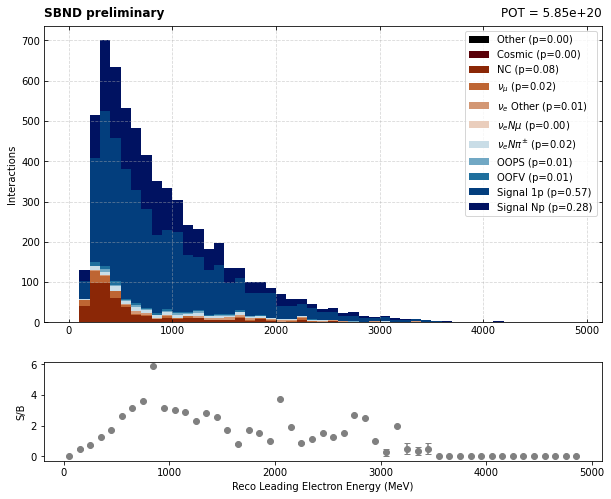

In [122]:
vals = fall['reco_leading_electron_energy'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 5000, 100),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Leading Electron Energy (MeV)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


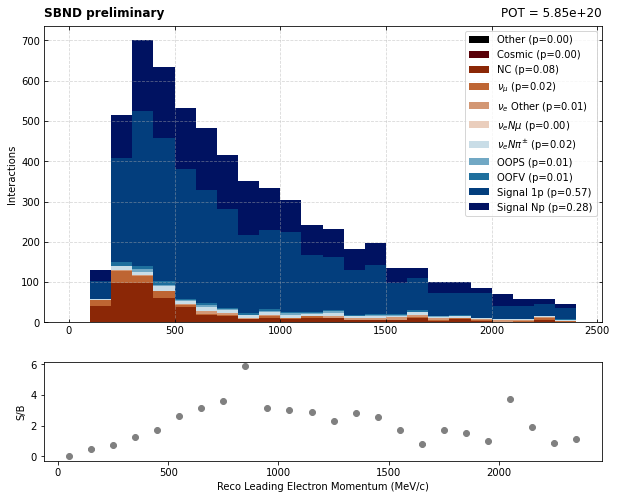

In [123]:
vals = fall['reco_leading_electron_p'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 2500, 100),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Leading Electron Momentum (MeV/c)",
    POT = totalPOT
)

/tmp/ipykernel_21116/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


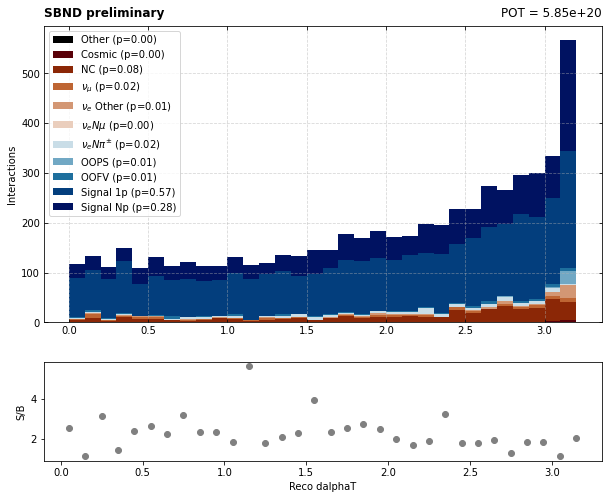

In [25]:
vals = fall['reco_dalphaT'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 3.3, 0.1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco dalphaT",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


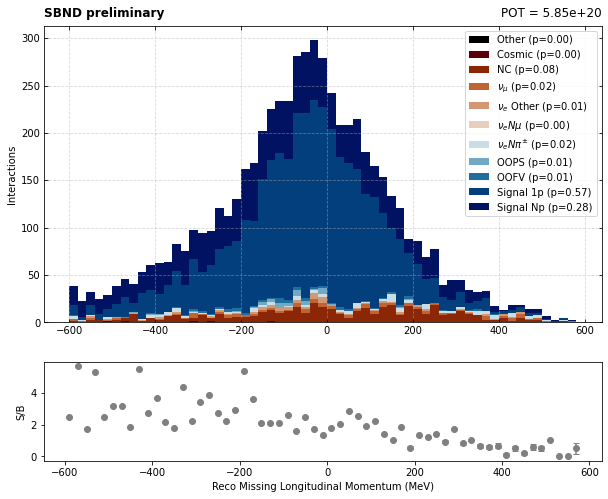

In [125]:
vals = fall['reco_dpL'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-600, 600, 20),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Missing Longitudinal Momentum (MeV)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


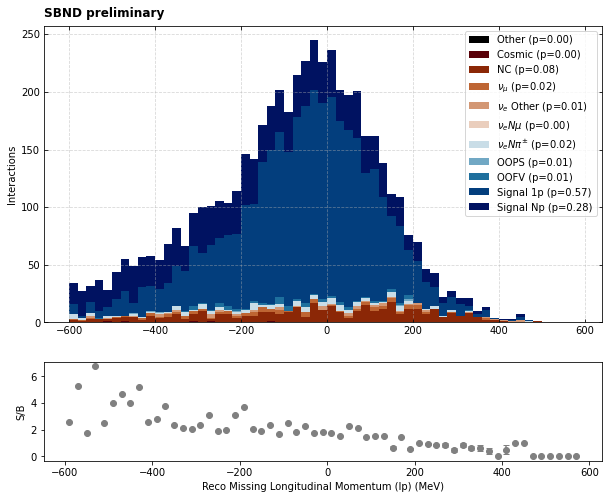

In [126]:
vals = fall['reco_dpL_lp'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-600, 600, 20),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Missing Longitudinal Momentum (lp) (MeV)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


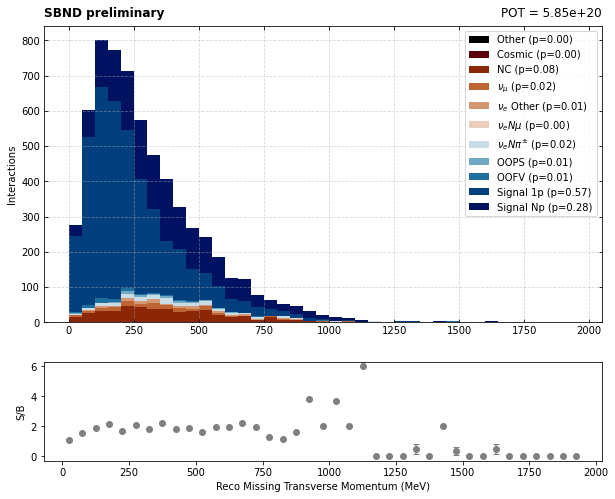

In [127]:
vals = fall['reco_dpT'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 2000, 50),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Missing Transverse Momentum (MeV)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


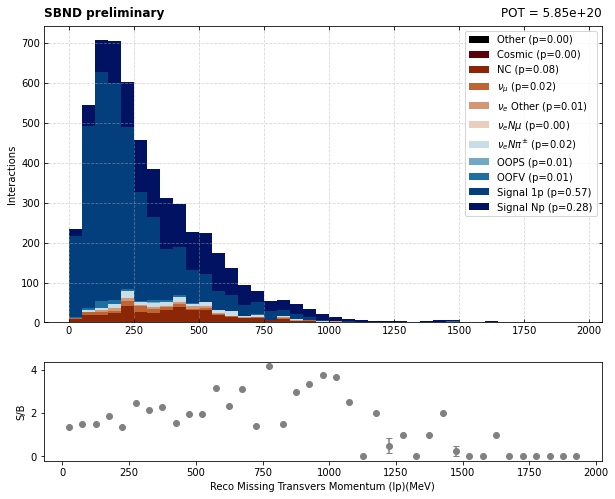

In [128]:
vals = fall['reco_dpT_lp'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 2000, 50),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Missing Transvers Momentum (lp)(MeV)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


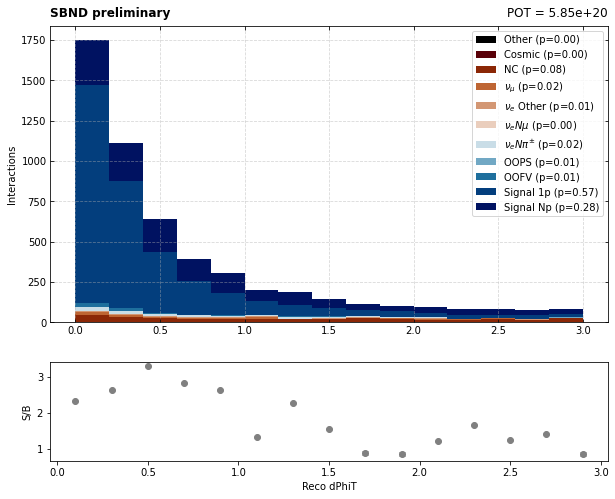

In [129]:
vals = fall['reco_dphiT'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 3.2, 0.2),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco dPhiT",
    POT = totalPOT
)

/tmp/ipykernel_21116/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


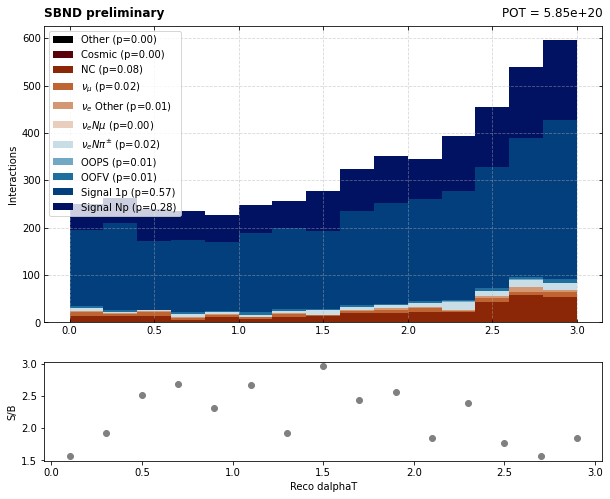

In [20]:
vals = fall['reco_dalphaT'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 3.2, 0.2),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco dalphaT",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


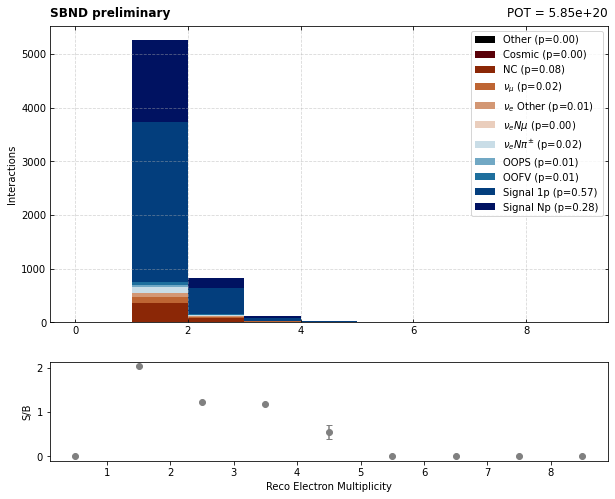

In [130]:
vals = fall['reco_electron_multiplicity'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 10, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Multiplicity",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


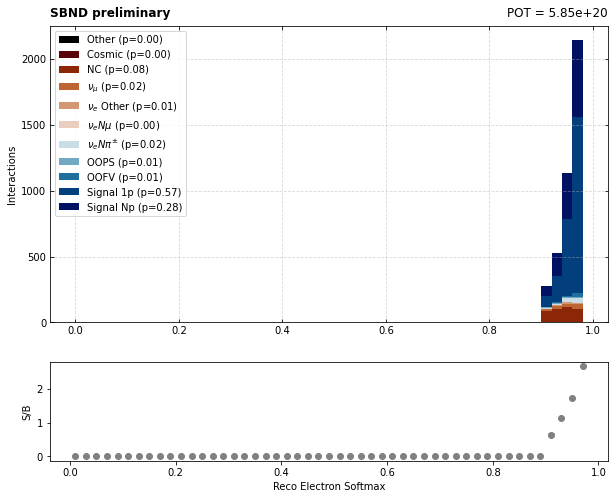

In [131]:
vals = fall['reco_leading_electron_electron_softmax'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 1, 0.02),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Softmax",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


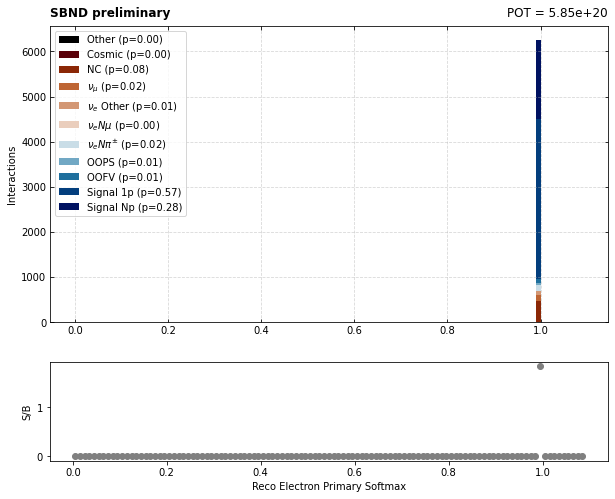

In [132]:
vals = fall['reco_leading_electron_primary_softmax'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 1.1, 0.01),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Primary Softmax",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


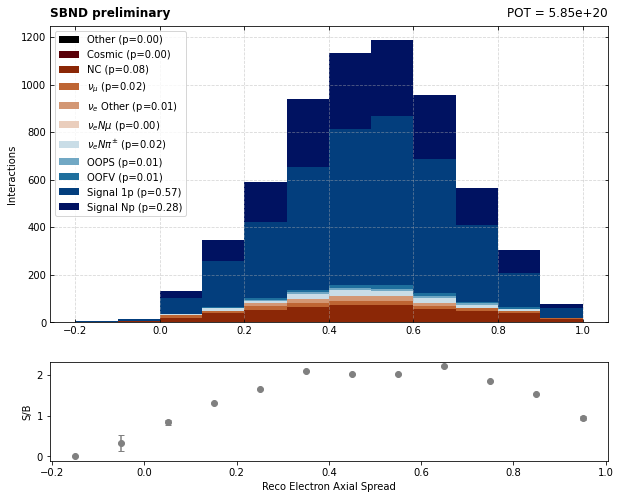

In [133]:
vals = fall['reco_leading_electron_axial_spread'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-0.2, 1.1, 0.1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Axial Spread",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


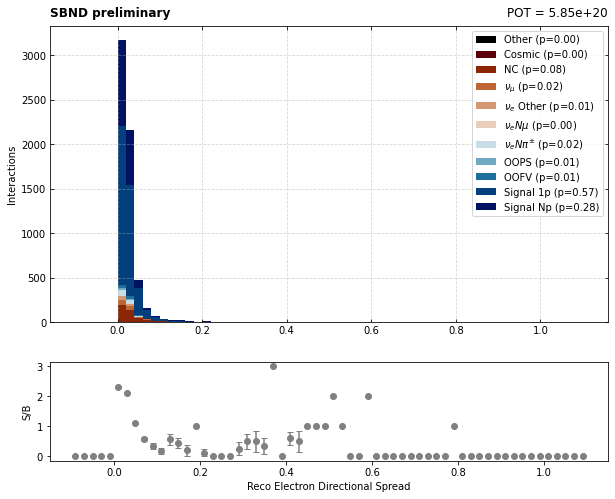

In [135]:
vals = fall['reco_leading_electron_directional_spread'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-0.1, 1.1, 0.02),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Directional Spread",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


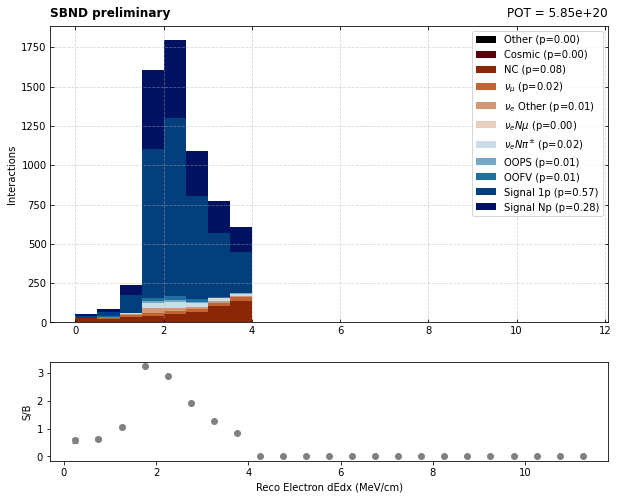

In [136]:
vals = fall['reco_leading_electron_start_dedx'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 12, 0.5),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron dEdx (MeV/cm)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


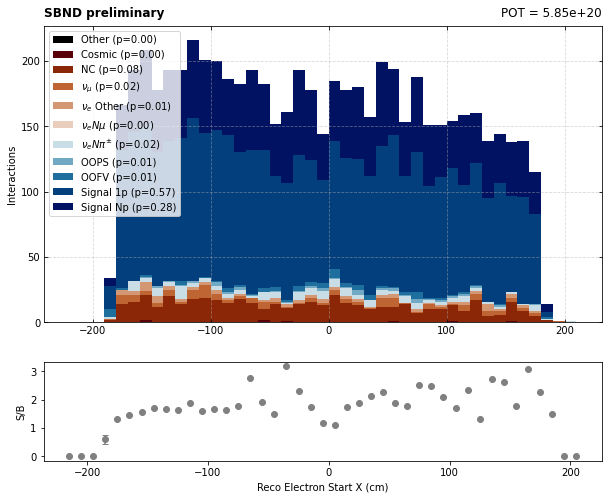

In [138]:
vals = fall['reco_leading_electron_start_x'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-220, 220, 10),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Start X (cm)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


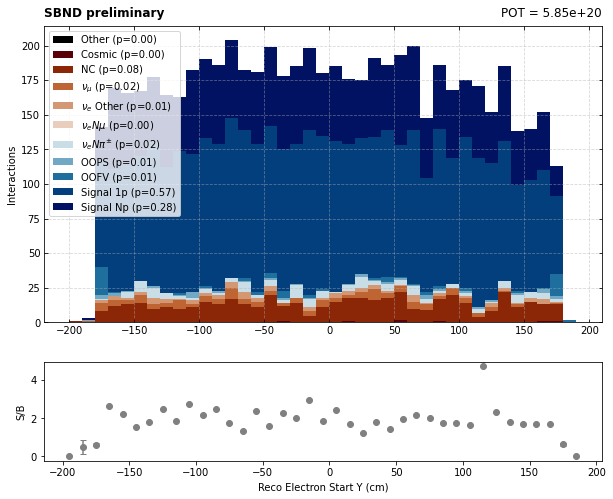

In [139]:
vals = fall['reco_leading_electron_start_y'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(-200, 200, 10),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Start Y (cm)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


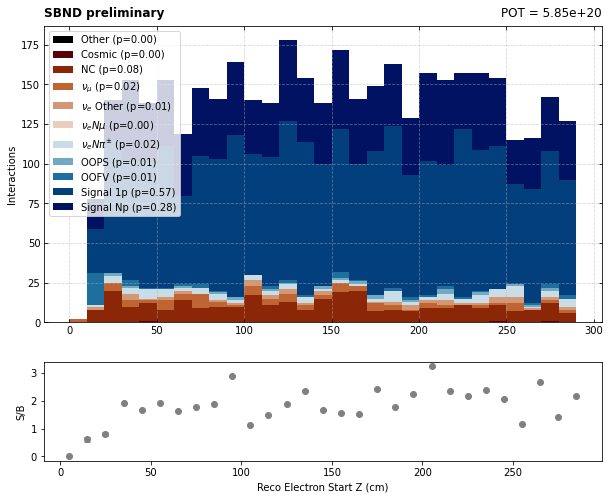

In [140]:
vals = fall['reco_leading_electron_start_z'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 300, 10),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Start Z (cm)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


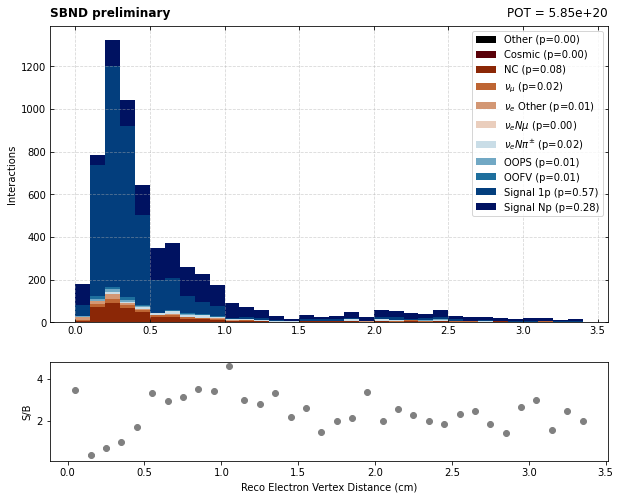

In [141]:
vals = fall['reco_leading_electron_vertex_distance'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 3.5, 0.1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Electron Vertex Distance (cm)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


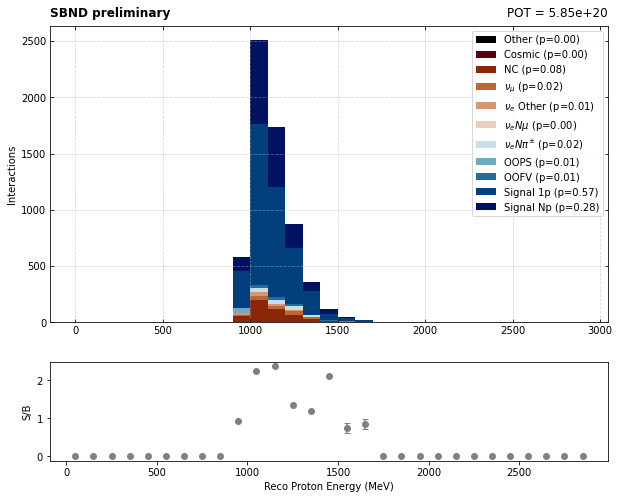

In [142]:
vals = fall['reco_leading_proton_energy'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 3000, 100),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton Energy (MeV)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


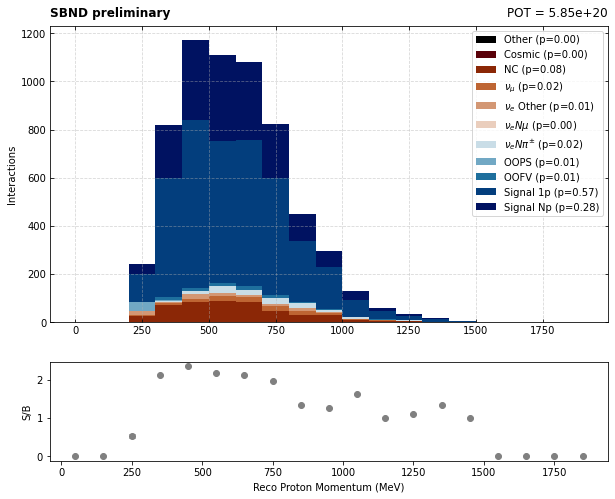

In [143]:
vals = fall['reco_leading_proton_p'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 2000, 100),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton Momentum (MeV)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


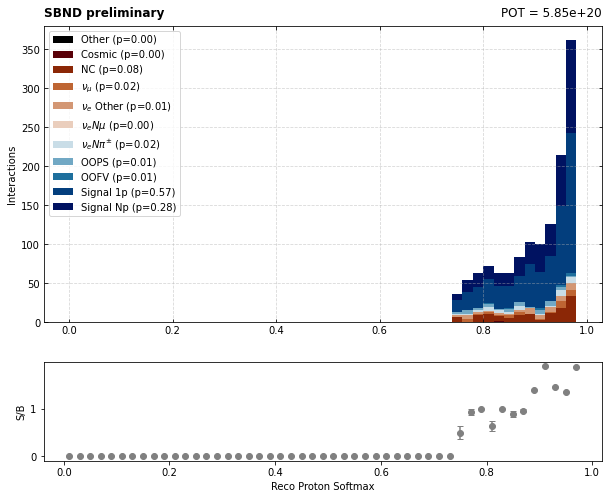

In [144]:
vals = fall['reco_leading_proton_proton_softmax'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 1, 0.02),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton Softmax",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


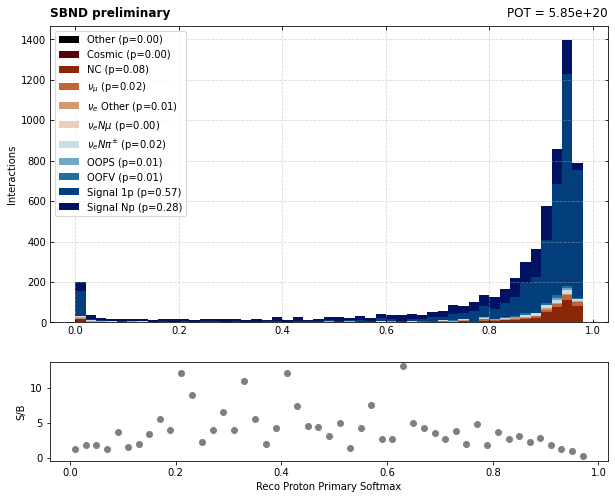

In [145]:
vals = fall['reco_leading_proton_primary_softmax'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 1, 0.02),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton Primary Softmax",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


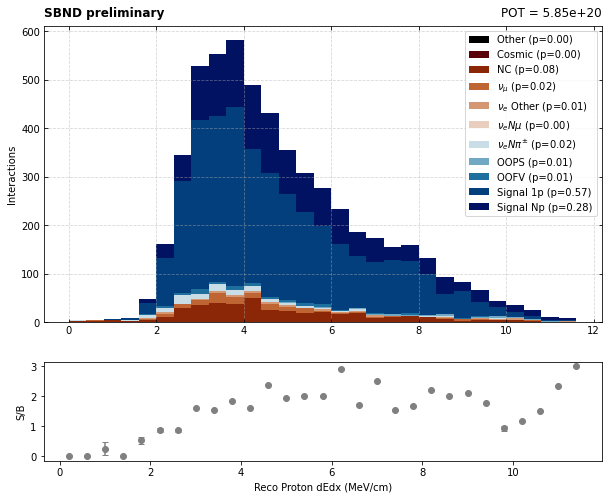

In [146]:
vals = fall['reco_leading_proton_start_dedx'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 12, 0.4),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton dEdx (MeV/cm)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


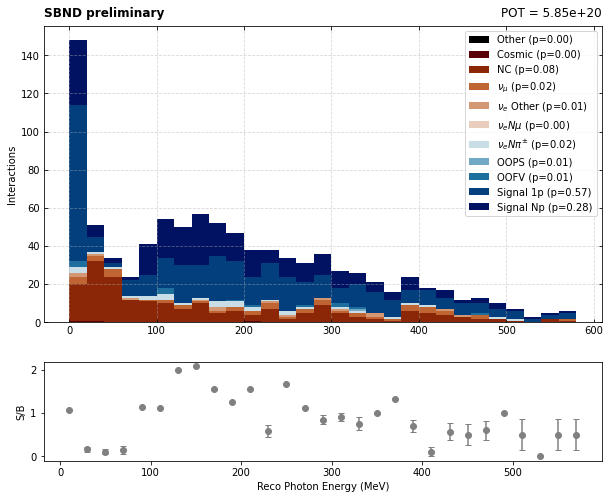

In [147]:
vals = fall['reco_leading_photon_energy'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 600, 20),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Photon Energy (MeV)",
    POT = totalPOT
)

[False False False ... False False False]


/home/micarrig/.local/lib/python3.9/site-packages/matplotlib/axes/_axes.py:6986: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  bins = np.histogram_bin_edges(
/home/micarrig/.local/lib/python3.9/site-packages/matplotlib/axes/_axes.py:7001: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)
/tmp/ipykernel_17375/2071045029.py:202: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  signal_hist, _ = np.histogram(l_vals[0], bins=bins)
/tmp/ipykernel_17375/2071045029.py:206: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  sel_hist, _ = np.histogram(background_vals, bins=bins)


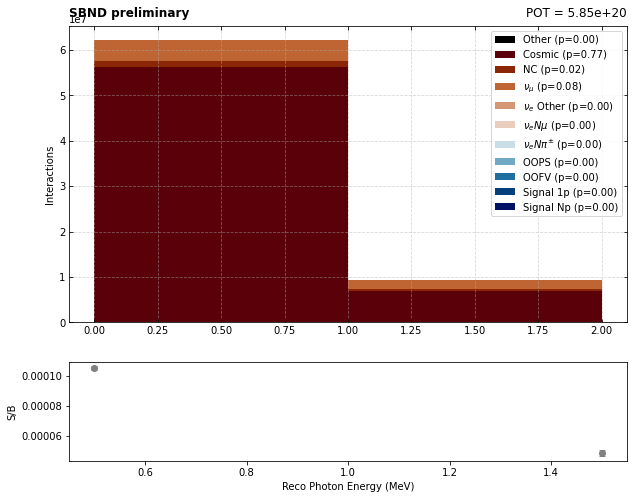

In [148]:
vals = fall['reco_leading_photon_energy'].array(library="np")
vals = np.where(vals < 50 | np.isnan(vals), True, False)
print(vals)
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals,
    bins=np.arange(0, 3, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category,
    title="Reco Photon Energy (MeV)",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


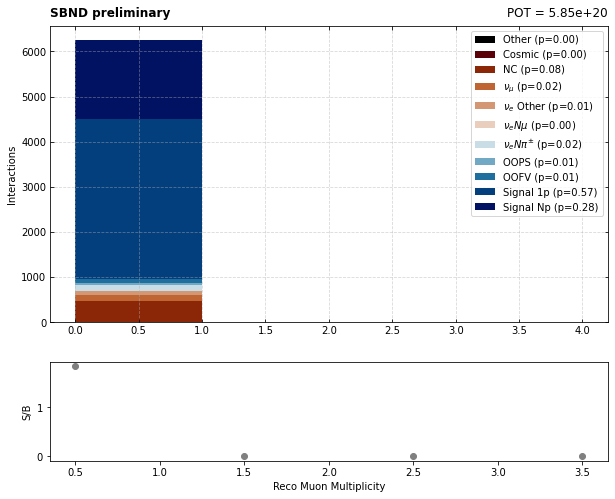

In [149]:
vals = fall['reco_muon_multiplicity'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 5, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Muon Multiplicity",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


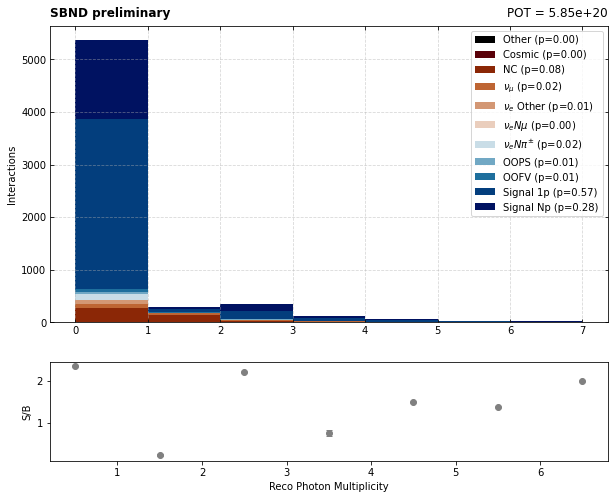

In [150]:
vals = fall['reco_photon_multiplicity'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 8, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Photon Multiplicity",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


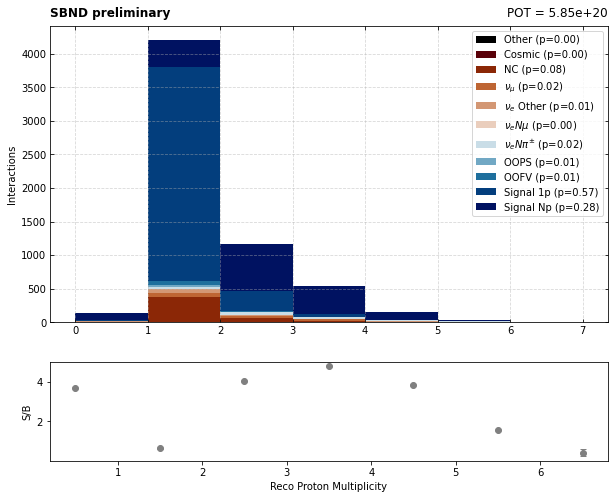

In [151]:
vals = fall['reco_proton_multiplicity'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 8, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Proton Multiplicity",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


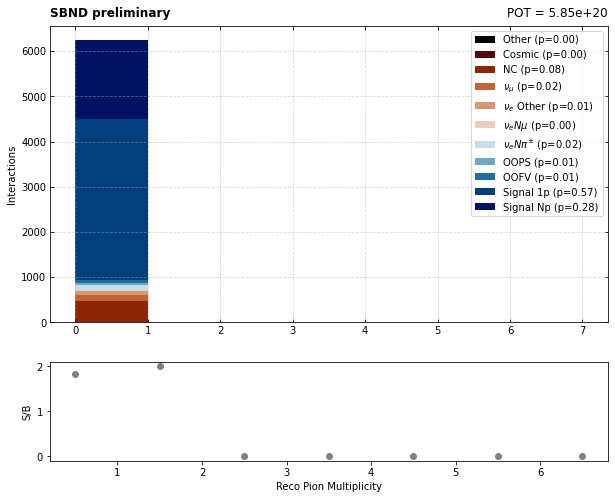

In [152]:
vals = fall['reco_pion_multiplicity'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 8, 1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Pion Multiplicity",
    POT = totalPOT
)

/tmp/ipykernel_17375/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


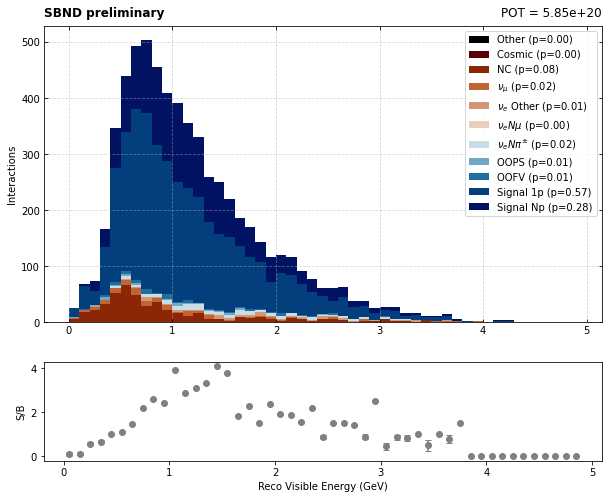

In [153]:
vals = fall['reco_visible_energy'].array(library="np")
vals_sel = vals[sel_mask]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 5, 0.1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Visible Energy (GeV)",
    POT = totalPOT
)

/tmp/ipykernel_21116/2071045029.py:214: RuntimeWarning: invalid value encountered in sqrt
  ratio_err = np.sqrt(


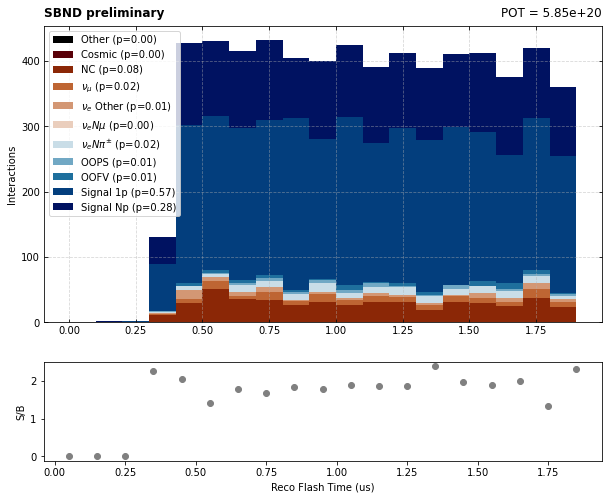

In [19]:
vals = fall['reco_flash_time'].array(library="np")
vals_sel = vals[sel_mask]

# vals = vals[true_category < 5]
# true_sel = true_category[true_category < 5]

ax, fig = plot_hist(
    vals=vals_sel,
    bins=np.arange(0, 2, 0.1),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="Reco Flash Time (us)", 
    POT = totalPOT
)

# print(type(ax))

# vals_good = (vals < 1.6) & (vals > 0)

# vals_high = vals >= 1.6
# vals_low = vals <= 0
# vals_nan = np.isnan(vals)

# print(f"fraction of selected events from flash match cut: {np.sum(vals_good)/len(vals) if len(vals) > 0 else 0:.4f}")
# print(f"fraction of selected events from flash match cut with high flash time: {np.sum(vals_high)/len(vals) if len(vals) > 0 else 0:.4f}")
# print(f"fraction of selected events from flash match cut with low flash time: {np.sum(vals_low)/len(vals) if len(vals) > 0 else 0:.4f}")
# print(f"fraction of selected events from flash match cut with NaN flash time: {np.sum(vals_nan)/len(vals) if len(vals) > 0 else 0:.4f}")

# ax[0].set_ylim(1, 1e4)
# ax[0].set_yscale('log')

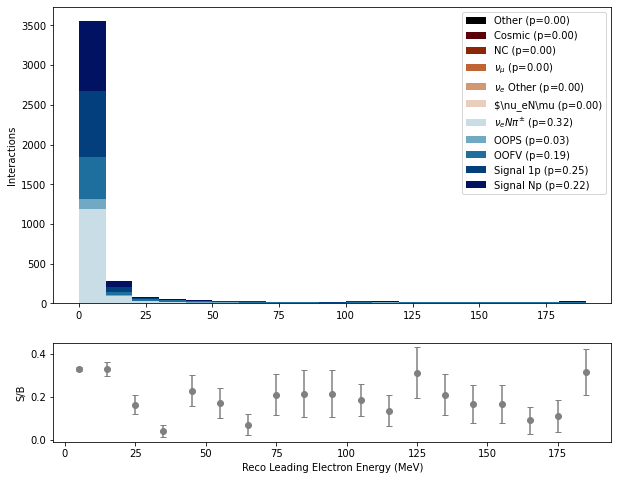

In [63]:
flash_time = fall['reco_flash_time'].array(library="np")

nue_mask = true_category < 5

nan_mask = np.isnan(flash_time)

vals = fall['reco_leading_electron_p'].array(library="np")
vals = vals[nue_mask & nan_mask]
true_sel = true_category[nue_mask & nan_mask]

ax, fig = plot_hist(
    vals=vals,
    bins=np.arange(0, 200, 10),
    labels=labels,
    colors=category_colors,
    truth_category=true_sel,
    title="Reco Leading Electron Energy (MeV)"
)

In [86]:
ele_e = fall['reco_leading_electron_ke'].array(library="np")
ele_cut = fall['reco_has_electron'].array(library="np")

print(f"fraction of events passing leading electron energy cut: {np.sum(ele_e > 25)/len(ele_e) if len(ele_e) > 0 else 0:.4f}")
print(f"fraction of events passing electron cut: {np.sum(ele_cut == 1)/len(ele_cut) if len(ele_cut) > 0 else 0:.4f}")

fraction of events passing leading electron energy cut: 0.2579
fraction of events passing electron cut: 0.0469


In [158]:
fall.keys()

['reco_containment_cut',
 'reco_cut_type',
 'reco_dalphaT',
 'reco_dpL',
 'reco_dpL_lp',
 'reco_dpT',
 'reco_dpT_lp',
 'reco_dphiT',
 'reco_ele_beam_open_angle',
 'reco_electron_multiplicity',
 'reco_electron_softmax_cut',
 'reco_fiducial_cut',
 'reco_flash_cut',
 'reco_flash_time',
 'reco_has_electron',
 'reco_has_proton',
 'reco_is_data',
 'reco_is_nu',
 'reco_leading_ele_energy_cut',
 'reco_leading_electron_axial_spread',
 'reco_leading_electron_azimuthal_angle',
 'reco_leading_electron_calo_ke',
 'reco_leading_electron_containment_cut',
 'reco_leading_electron_csda_ke',
 'reco_leading_electron_directional_spread',
 'reco_leading_electron_electron_softmax',
 'reco_leading_electron_end_dir_x',
 'reco_leading_electron_end_dir_y',
 'reco_leading_electron_end_dir_z',
 'reco_leading_electron_end_x',
 'reco_leading_electron_end_y',
 'reco_leading_electron_end_z',
 'reco_leading_electron_energy',
 'reco_leading_electron_ke',
 'reco_leading_electron_length',
 'reco_leading_electron_mcs_ke',

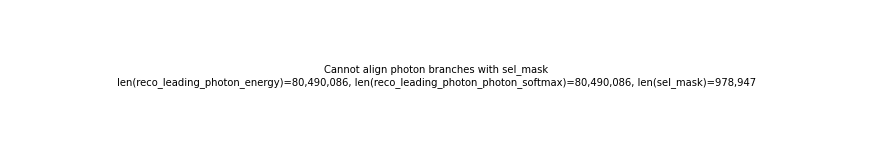

In [392]:
from matplotlib.colors import LogNorm
import awkward as ak

# Two panels only. Each panel is a 2D histogram with log(z) color scaling + colorbar,
# and an annotation showing the histogram counts and fraction of total entries (for that panel).

var_x = "reco_leading_photon_energy"
var_y = "reco_leading_photon_photon_softmax"

samples = [
    ("Signal Events", 0),
    (r"Other nuE", 1),
]

# Bin edges
xbins = np.linspace(0, 2500, 51)  # 50 bins
ybins = np.linspace(0, 1, 21)     # 20 bins

def _event_level_numpy(tree, branch_name: str) -> np.ndarray:
    """Return one value per tree entry (best-effort), even if the branch is jagged."""
    arr = tree[branch_name].array(library="ak")
    try:
        ak.num(arr, axis=1)
        arr = ak.firsts(arr)
    except Exception:
        pass
    return np.asarray(ak.to_numpy(ak.fill_none(arr, np.nan)), dtype=float)

# Read once (avoid repeated I/O inside the loop)
x_all = _event_level_numpy(fall, var_x)
y_all = _event_level_numpy(fall, var_y)

if x_all.shape[0] != sel_mask.shape[0] or y_all.shape[0] != sel_mask.shape[0]:
    fig, ax = plt.subplots(figsize=(12, 2), constrained_layout=True)
    ax.text(
        0.5, 0.5,
        "Cannot align photon branches with sel_mask\n"
        f"len({var_x})={x_all.shape[0]:,}, len({var_y})={y_all.shape[0]:,}, len(sel_mask)={sel_mask.shape[0]:,}",
        ha="center", va="center", transform=ax.transAxes,
    )
    ax.axis("off")
    plt.show()
else:
    # Apply the common selection mask once; categories are already aligned to sel_mask
    x_base = x_all[sel_mask]
    y_base = y_all[sel_mask]
    cat_base = true_category_sel

    finite = np.isfinite(x_base) & np.isfinite(y_base)
    x_base = x_base[finite]
    y_base = y_base[finite]
    cat_base = cat_base[finite]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 6),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    for ax, (title, index) in zip(axes, samples):
        ax.set_title(title)
        ax.set_xlabel("Reco Leading Photon Energy (MeV)")
        ax.set_ylabel("Reco Leading Photon Score")
        ax.grid(alpha=0.3)

        this_cat = (cat_base == index)
        x = x_base[this_cat]
        y = y_base[this_cat]

        if x.size == 0 or y.size == 0:
            ax.text(0.5, 0.5, "No entries", ha="center", va="center", transform=ax.transAxes)
            continue

        h, xedges, yedges = np.histogram2d(x, y, bins=[xbins, ybins])
        h_masked = np.ma.masked_less_equal(h, 0)
        vmax = max(1.0, float(h.max()))

        im = ax.pcolormesh(
            xedges,
            yedges,
            h_masked.T,
            cmap="viridis",
            norm=LogNorm(vmin=1.0, vmax=vmax),
            shading="auto",
        )
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Counts")

        n_total = int(x.size)
        n_in_hist = int(h.sum())
        frac = (n_in_hist / n_total) if n_total > 0 else 0.0
        ax.text(
            0.02, 0.98,
            f"In hist: {n_in_hist:,} / {n_total:,}\nFrac: {frac:.2%}",
            transform=ax.transAxes,
            ha="left", va="top",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="none"),
        )

    plt.show()

In [134]:
fall.keys()

['reco_containment_cut',
 'reco_cut_type',
 'reco_dalphaT',
 'reco_dpL',
 'reco_dpL_lp',
 'reco_dpT',
 'reco_dpT_lp',
 'reco_dphiT',
 'reco_ele_beam_open_angle',
 'reco_electron_multiplicity',
 'reco_electron_softmax_cut',
 'reco_fiducial_cut',
 'reco_flash_cut',
 'reco_flash_time',
 'reco_has_electron',
 'reco_has_proton',
 'reco_is_data',
 'reco_is_nu',
 'reco_leading_ele_energy_cut',
 'reco_leading_electron_axial_spread',
 'reco_leading_electron_azimuthal_angle',
 'reco_leading_electron_calo_ke',
 'reco_leading_electron_containment_cut',
 'reco_leading_electron_csda_ke',
 'reco_leading_electron_directional_spread',
 'reco_leading_electron_electron_softmax',
 'reco_leading_electron_end_dir_x',
 'reco_leading_electron_end_dir_y',
 'reco_leading_electron_end_dir_z',
 'reco_leading_electron_end_x',
 'reco_leading_electron_end_y',
 'reco_leading_electron_end_z',
 'reco_leading_electron_energy',
 'reco_leading_electron_ke',
 'reco_leading_electron_length',
 'reco_leading_electron_mcs_ke',

In [ ]:
true_leading_electron_energy = fall['true_leading_electron_energy'].array(library="np")
true_leading_electron_energy_sel = true_leading_electron_energy[sel_mask]

ax, fig = plot_hist(
    vals=true_leading_electron_energy_sel,
    bins=np.arange(0, 5000, 100),
    labels=labels,
    colors=category_colors,
    truth_category=true_category_sel,
    title="True Leading Electron Energy (MeV)"
)

## Test different selections to maximize efficiency/purity

In [167]:
fall.keys()

['reco_containment_cut',
 'reco_cut_type',
 'reco_dalphaT',
 'reco_dpL',
 'reco_dpL_lp',
 'reco_dpT',
 'reco_dpT_lp',
 'reco_dphiT',
 'reco_ele_beam_open_angle',
 'reco_electron_multiplicity',
 'reco_electron_softmax_cut',
 'reco_fiducial_cut',
 'reco_flash_cut',
 'reco_flash_time',
 'reco_has_electron',
 'reco_has_proton',
 'reco_is_data',
 'reco_is_nu',
 'reco_leading_ele_energy_cut',
 'reco_leading_electron_axial_spread',
 'reco_leading_electron_azimuthal_angle',
 'reco_leading_electron_calo_ke',
 'reco_leading_electron_containment_cut',
 'reco_leading_electron_csda_ke',
 'reco_leading_electron_directional_spread',
 'reco_leading_electron_electron_softmax',
 'reco_leading_electron_end_dir_x',
 'reco_leading_electron_end_dir_y',
 'reco_leading_electron_end_dir_z',
 'reco_leading_electron_end_x',
 'reco_leading_electron_end_y',
 'reco_leading_electron_end_z',
 'reco_leading_electron_energy',
 'reco_leading_electron_ke',
 'reco_leading_electron_length',
 'reco_leading_electron_mcs_ke',

In [55]:
selections = []
selections.append(selection("reco_no_cut", "No Cut"))
selections.append(selection("reco_fiducial_cut", "Fiducial Cut", operator='==', threshold=1, nan_val=0))
# selections.append(selection("reco_flash_cut", "Flash Cut", operator='==', threshold=1, nan_val=-999))
selections.append(selection("reco_valid_flashmatch", "Valid Flash Match", operator='==', threshold=1, nan_val=-999))
selections.append(selection("reco_containment_cut", "Interaction Containment Cut"))
# selections.append(selection("reco_has_electron", ">=1 Electron-like Particle"))
# selections.append(selection("reco_no_muons", "0 Muon-like Particles", operator='==', threshold=1))
selections.append(selection("reco_leading_muon_p", "0 Muon-like Particles", operator='==', threshold=1, nan_val=-1, sel="np.where((branch_array < 25), 1, 0)"))
# selections.append(selection("reco_no_charged_pions", "0 Charged Pion-like Particles", operator='==', threshold=1))
selections.append(selection("reco_leading_pion_p", "0 Charged Pion-like Particles", operator='==', threshold=1, nan_val=-1, sel="np.where((branch_array < 25), 1, 0)"))
# selections.append(selection("reco_has_proton", ">=1 Proton-like Particle"))
selections.append(selection("reco_leading_proton_p", "Leading Proton Momentum > 40 MeV", operator='>', threshold=40, nan_val=-999))
selections.append(selection("reco_leading_electron_electron_softmax", "Leading Electron Softmax > 0.90", operator='>', threshold=0.90))
selections.append(selection("reco_leading_electron_primary_softmax", "Leading Electron Primary Softmax > 0.99", operator='>', threshold=0.99))
selections.append(selection("reco_leading_proton_proton_softmax", "Leading Proton Softmax > 0.75", operator='>', threshold=0.75))
# selections.append(selection("reco_leading_electron_axial_spread", "Leading Electron Axial Spread > 0.1", operator='>', threshold=0.1))
# selections.append(selection("reco_leading_photon_energy", "Leading Photon Energy < 150 MeV", operator='==', threshold=1, sel="np.where((branch_array < 150), 1, 0)", nan_val=-999))
selections.append(selection("reco_leading_electron_p", "Leading Electron Momentum > 75 MeV", operator='>', threshold=75))
selections.append(selection("reco_leading_electron_vertex_distance", "Leading Electron Vertex Distance < 3.5 cm", operator='<', threshold=3.5))
selections.append(selection("reco_leading_electron_start_dedx", "Leading Electron dEdx < 4 MeV/cm", operator='<', threshold=4))
selections.append(selection("reco_single_tpc_contained", "Interaction Single-TPC Contained", operator='==', threshold=1, nan_val=-999))


In [56]:
bins = [0, 225, 350, 500, 650, 800, 1000, 1250, 1500, 2000, 5000]

eleE = ak.nan_to_num(fall['true_leading_electron_energy'].array(), -1)
true_category = fall['true_category'].array()
total_entries = ak.sum(((true_category == 0) | (true_category == 1)))
eff_var = ak.to_numpy(ak.where(((true_category == 0) | (true_category == 1)), 1, 0))

print("Total signal events for efficiency calculation:", total_entries)
hists = get_effHists('true_leading_electron_energy', fall, selections, eff_var = eff_var, signal_index=1, total=total_entries, bins=arr.array('d', bins), xmin=0, xmax=5000)

# total_entries = ak.sum(fevt['event_nnu_e'].array())
# hists = get_effHists('true_leading_electron_energy', fall, selections, total=total_entries, bins=arr.array('d', bins), xmin=0, xmax=5000)

c, l = plot_hists(hists, selections, "Leading Electron Energy Efficiency", "Leading Electron Energy (MeV)", "Efficiency", range=(0.01, 1.2))
c.SetLogy(0)
c.Draw()
l.Draw()

Total signal events for efficiency calculation: 50
Using provided efficiency variable array
Unique values in efficiency variable: [0, 1]
Applying selection: No Cut
total entries in selection: 325873
Selected entries: 325873
Purity: 50/325873 = 0.0002
Efficiency after No Cut: 1.0000 (50/50)
Applying selection: Fiducial Cut
total entries in selection: 111781
Selected entries: 111781
Purity: 48/111781 = 0.0004
Efficiency after Fiducial Cut: 0.9600 (48/50)
Applying selection: Valid Flash Match
total entries in selection: 15291
Selected entries: 15291
Purity: 37/15291 = 0.0024
Efficiency after Valid Flash Match: 0.7400 (37/50)
Applying selection: Interaction Containment Cut
total entries in selection: 9069
Selected entries: 9069
Purity: 37/9069 = 0.0041
Efficiency after Interaction Containment Cut: 0.7400 (37/50)
Applying selection: 0 Muon-like Particles
Applying custom selection function: np.where((branch_array < 25), 1, 0) [1.15e+04, 477, 1.5e+03, -1, 1e+05, 1.42e+03, ..., 945, -1, 583, 1

Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_num (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_den (Potential memory leak).
Warn

In [57]:
print_selection_stats(selections)


Selection Summary
Selection                                  Slice/Int Efficiency  Neutrino Efficiency        Purity      
--------------------------------------------------------------------------------------------------------
No Cut                                           1.0000 (50/50)       1.0000 (50/50)  0.0002 (50/325873)
Fiducial Cut                                     0.9600 (48/50)       0.9600 (48/50)  0.0004 (48/111781)
Valid Flash Match                                0.7400 (37/50)       0.7400 (37/50)   0.0024 (37/15291)
Interaction Containment Cut                      0.7400 (37/50)       0.7400 (37/50)    0.0041 (37/9069)
0 Muon-like Particles                            0.7200 (36/50)       0.7200 (36/50)    0.0082 (36/4370)
0 Charged Pion-like Particles                    0.6200 (31/50)       0.6200 (31/50)    0.0087 (31/3545)
Leading Proton Momentum > 40 MeV                 0.5800 (29/50)       0.5800 (29/50)    0.0103 (29/2824)
Leading Electron Softmax > 0.90     

In [318]:
hists = get_varHists('true_leading_electron_energy', fall, bins=50, xmin=0, xmax=5000)
c, l = plot_hists(hists, selections, "Leading Electron Energy after Selections", "Reconstructed Leading Electron Energy [MeV]", "Entries", range=(1, 10e7))
c.Draw()
l.Draw()

Applying selection: No Cut
Efficiency after No Cut: 1.0000 (185/185)
Applying selection: Fiducial Cut
Efficiency after Fiducial Cut: 0.9444 (175/185)
Applying selection: Flash Cut
Efficiency after Flash Cut: 0.7531 (141/185)
Applying selection: Interaction Containment Cut
Efficiency after Interaction Containment Cut: 0.7531 (141/185)
Applying selection: Vertex Distance < 3.25 cm
Efficiency after Vertex Distance < 3.25 cm: 0.6667 (122/185)
Applying selection: >=1 Electron-like Particle
Efficiency after >=1 Electron-like Particle: 0.6667 (122/185)
Applying selection: 0 Muon-like Particles
Efficiency after 0 Muon-like Particles: 0.6667 (122/185)
Applying selection: 0 Charged Pion-like Particles
Efficiency after 0 Charged Pion-like Particles: 0.6358 (117/185)
Applying selection: >=1 Proton-like Particle
Efficiency after >=1 Proton-like Particle: 0.5802 (107/185)
Applying selection: Leading Electron Softmax > 0.72
Efficiency after Leading Electron Softmax > 0.72: 0.5741 (106/185)
Applying s

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: 

## Fix Efficiency Plots

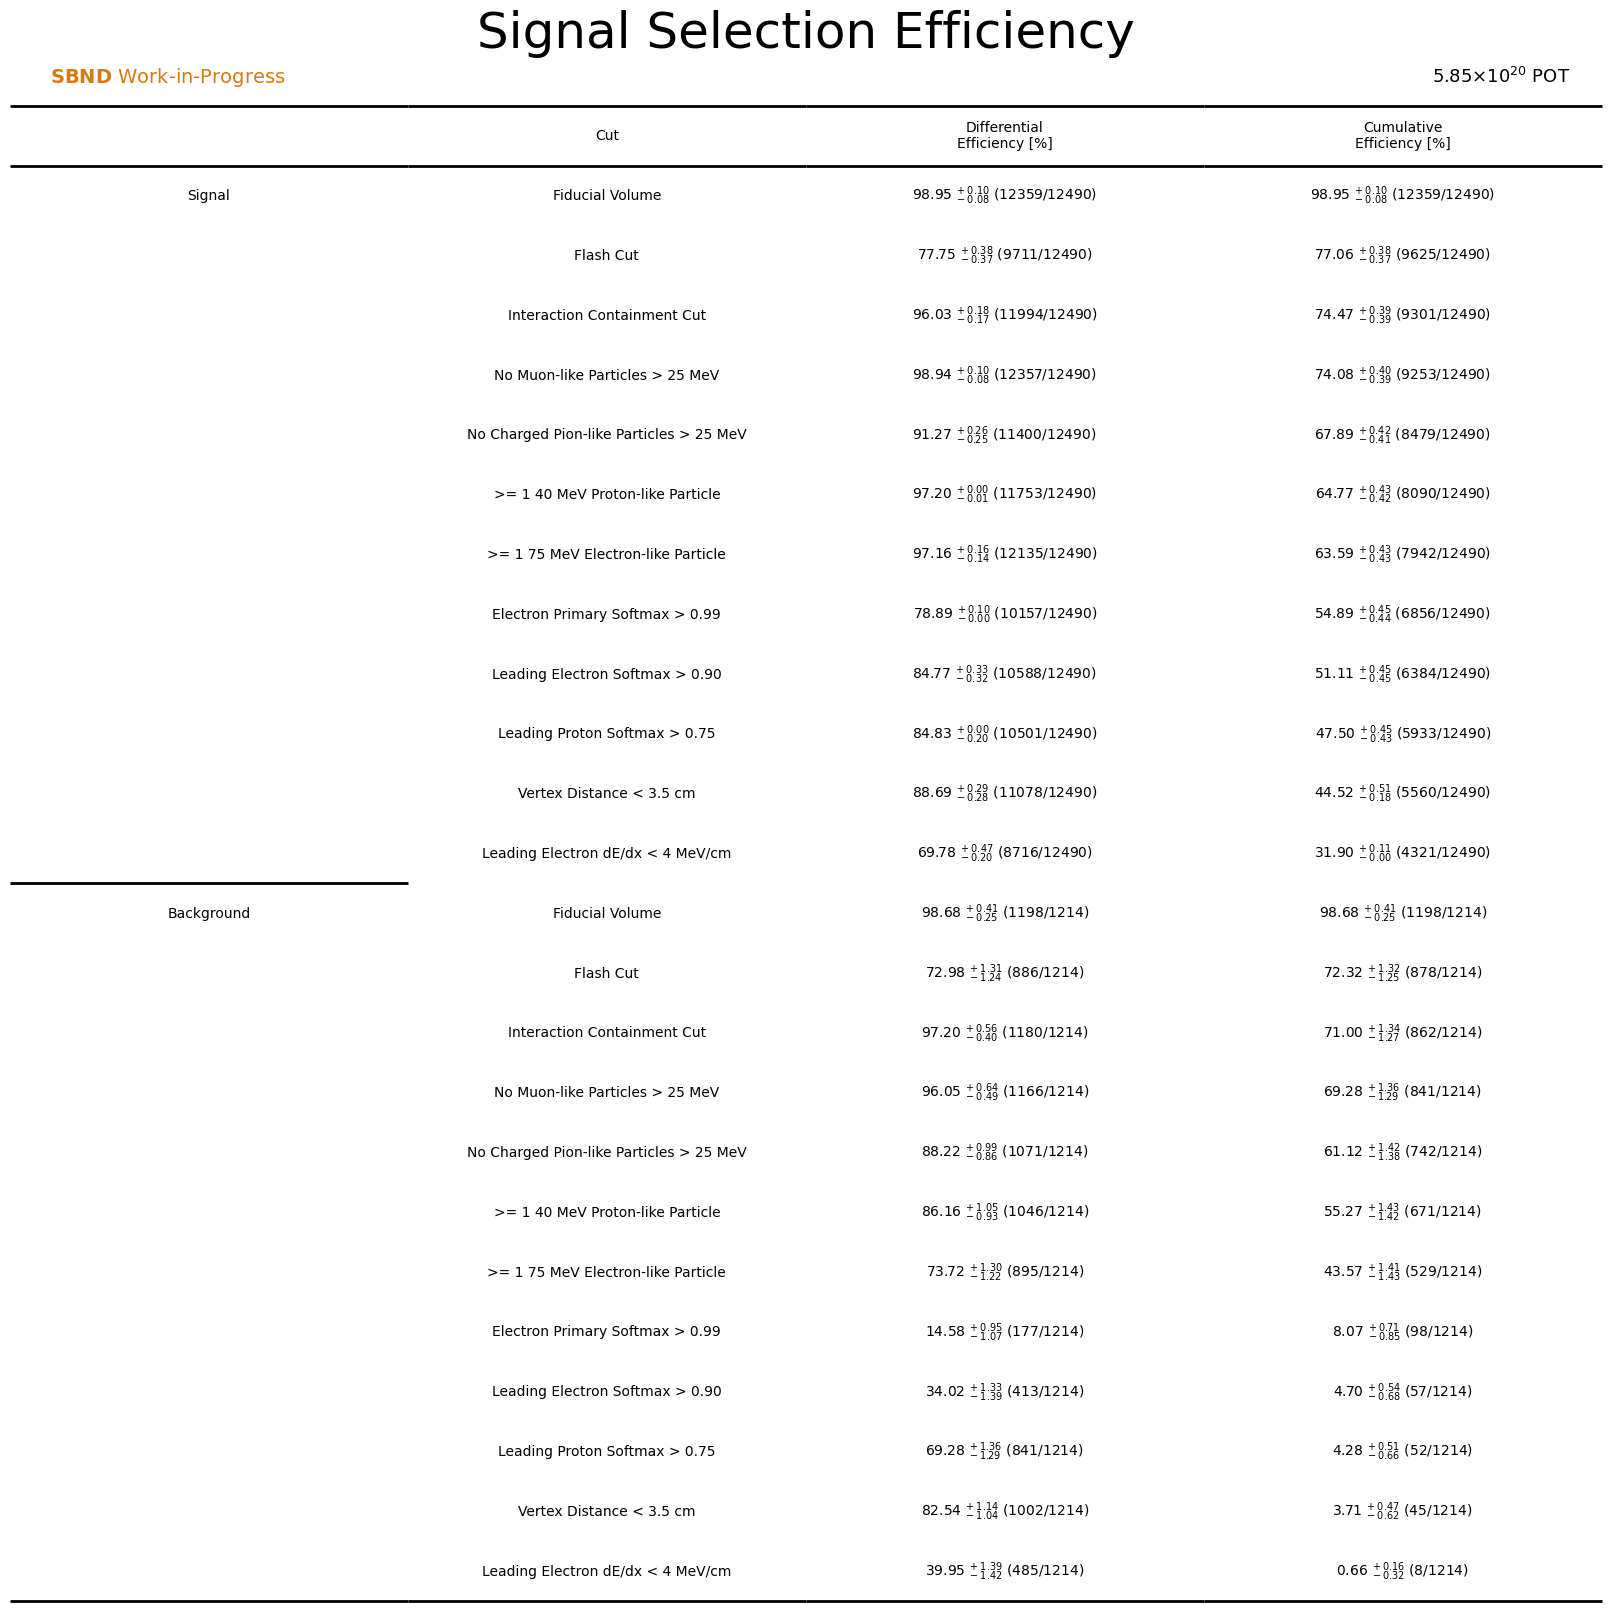

In [30]:
with open('/nashome/m/micarrig/sbnd/nueCCNp/plots/selection_efficiency_trueTree/selection_efficiency_table.pkl', 'rb') as f:
    eff = pickle.load(f)
    eff.set_size_inches(16, 16)
    ax = eff.axes[0]
    table = ax.tables[0]
    table.auto_set_font_size(False)
    table.set_fontsize(10)

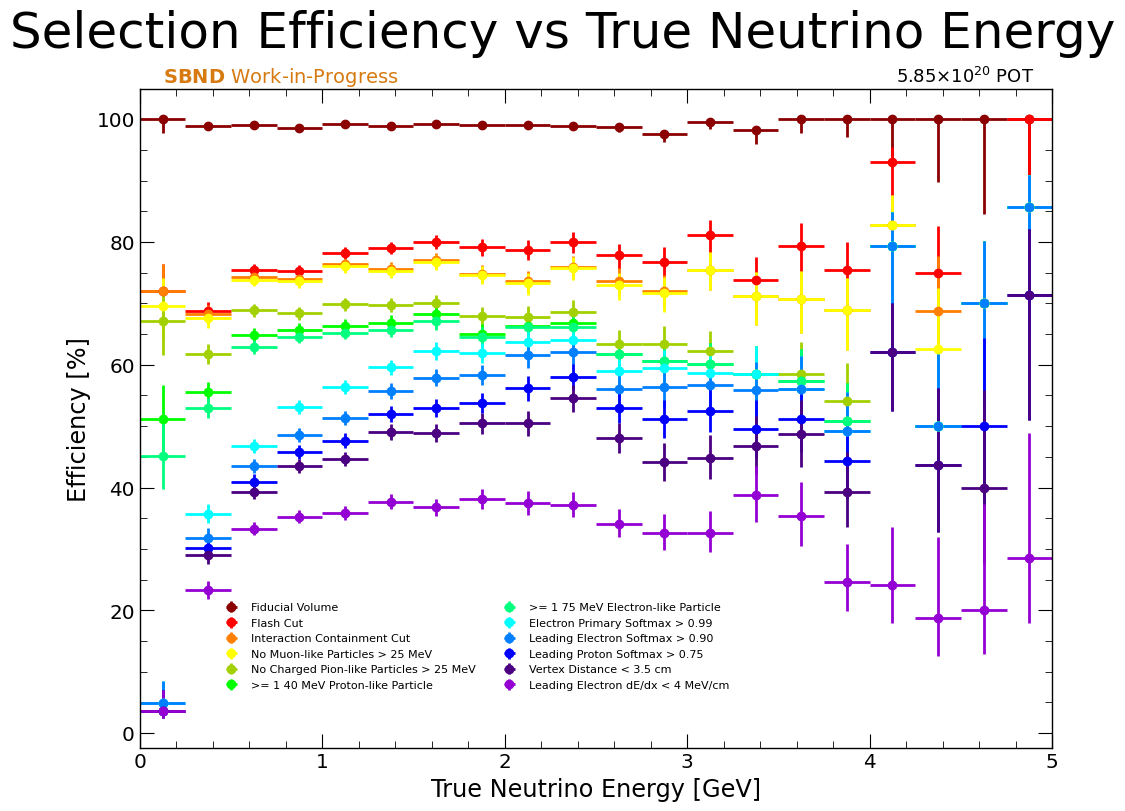

In [41]:
with open('/nashome/m/micarrig/sbnd/nueCCNp/plots/selection_efficiency_trueTree/efficiency_vs_energy.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)
    ax = eff_nuE.axes[0]
    legend = ax.get_legend()
    if legend is not None:
        legend_loc = legend._loc
        legend_bbox = legend.get_bbox_to_anchor()._bbox
        legend_frame = legend.get_frame_on()
        handles, labels = ax.get_legend_handles_labels()
        legend.remove()
        legend = ax.legend(handles, labels, ncol=2, fontsize=8, frameon=legend_frame, loc=legend_loc, bbox_to_anchor=legend_bbox)
        if legend.get_title() is not None:
            legend.get_title().set_fontsize(8)

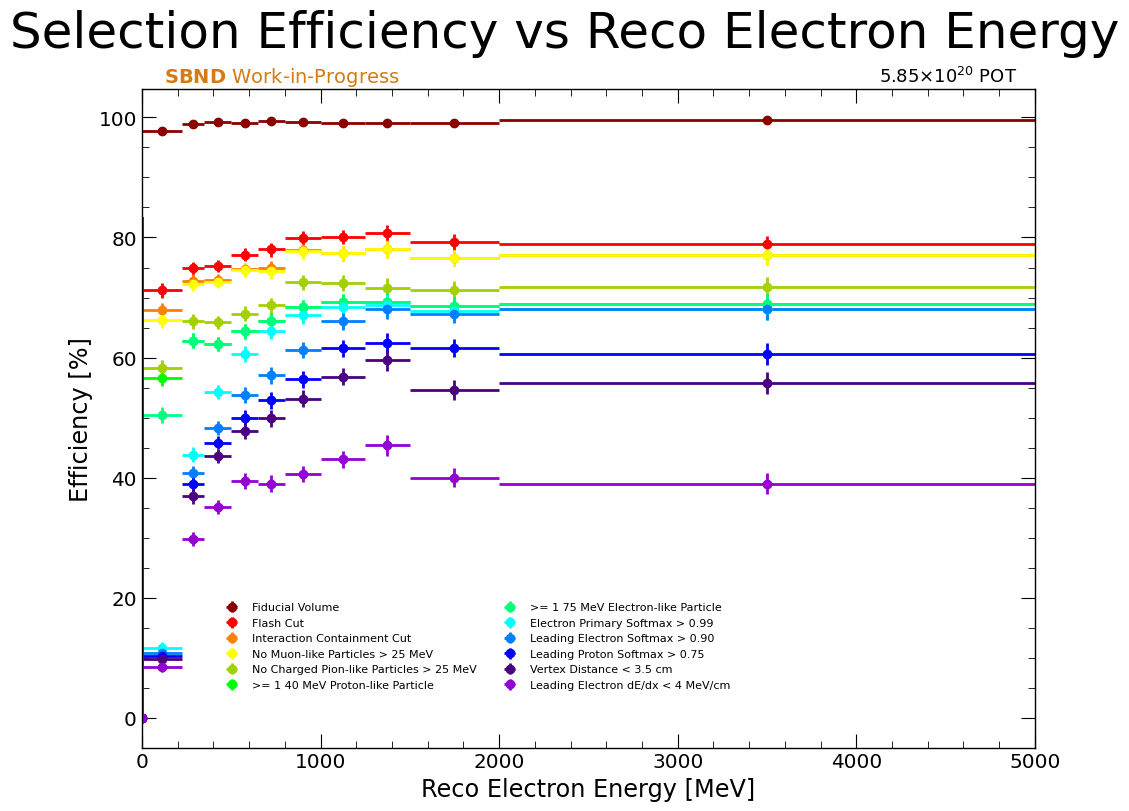

In [47]:
with open('/nashome/m/micarrig/sbnd/nueCCNp/plots/selection_efficiency_trueTree/efficiency_vs_electronEnergy.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)
    ax = eff_nuE.axes[0]
    legend = ax.get_legend()
    if legend is not None:
        legend_loc = legend._loc
        legend_bbox = legend.get_bbox_to_anchor()._bbox
        legend_frame = legend.get_frame_on()
        handles, labels = ax.get_legend_handles_labels()
        legend.remove()
        legend = ax.legend(handles, labels, ncol=2, fontsize=8, frameon=legend_frame, loc=legend_loc, bbox_to_anchor=legend_bbox)
        if legend.get_title() is not None:
            legend.get_title().set_fontsize(8)

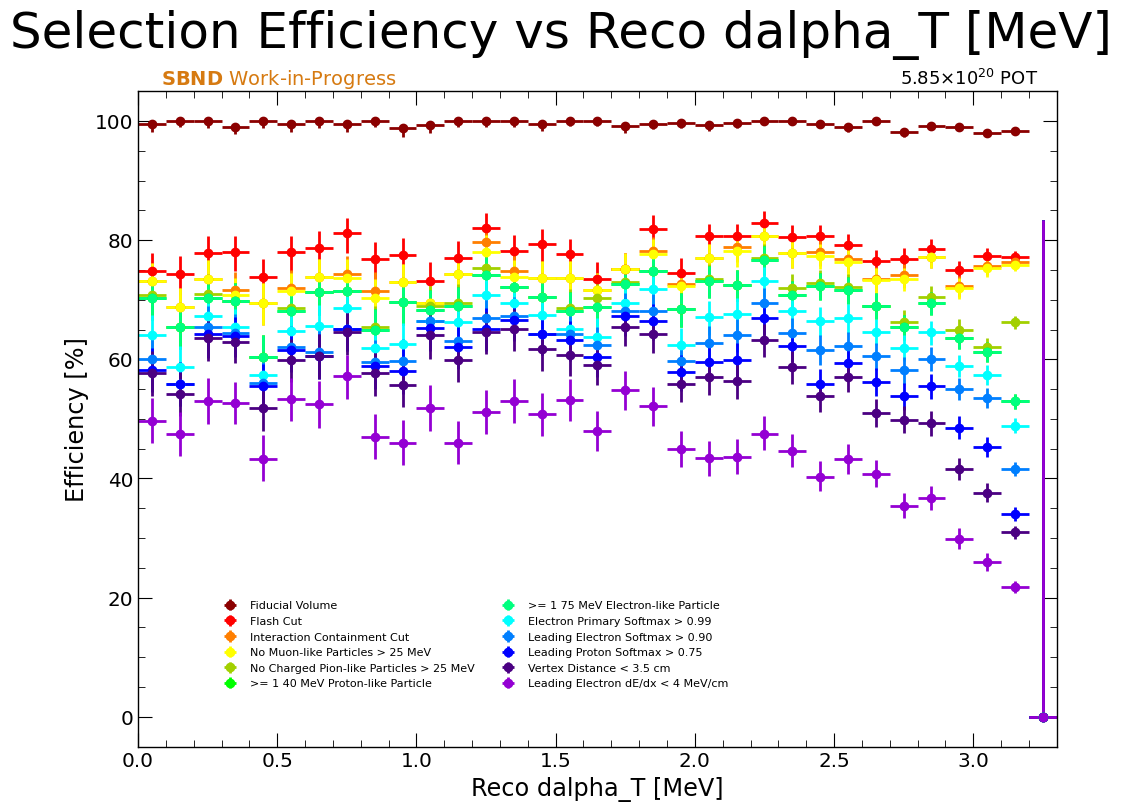

In [48]:
with open('/nashome/m/micarrig/sbnd/nueCCNp/plots/selection_efficiency_trueTree/efficiency_vs_recoDalphaT.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)
    ax = eff_nuE.axes[0]
    legend = ax.get_legend()
    if legend is not None:
        legend_loc = legend._loc
        legend_bbox = legend.get_bbox_to_anchor()._bbox
        legend_frame = legend.get_frame_on()
        handles, labels = ax.get_legend_handles_labels()
        legend.remove()
        legend = ax.legend(handles, labels, ncol=2, fontsize=8, frameon=legend_frame, loc=legend_loc, bbox_to_anchor=legend_bbox)
        if legend.get_title() is not None:
            legend.get_title().set_fontsize(8)

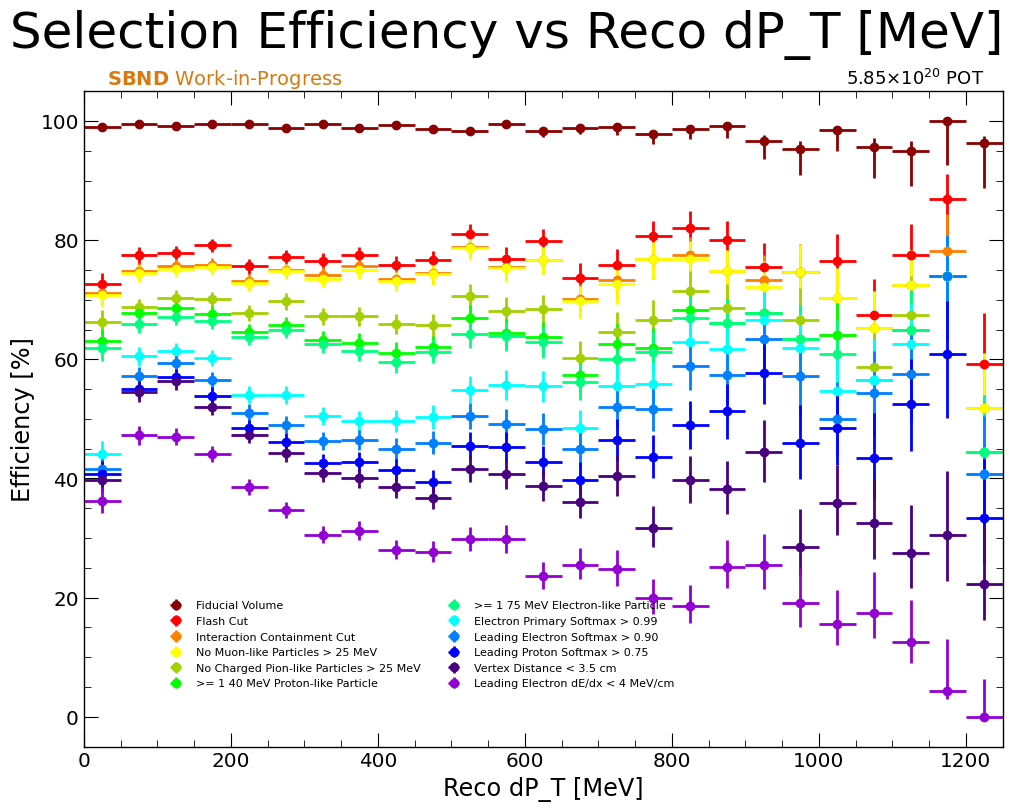

In [49]:
with open('/nashome/m/micarrig/sbnd/nueCCNp/plots/selection_efficiency_trueTree/efficiency_vs_recoDPT.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)
    ax = eff_nuE.axes[0]
    legend = ax.get_legend()
    if legend is not None:
        legend_loc = legend._loc
        legend_bbox = legend.get_bbox_to_anchor()._bbox
        legend_frame = legend.get_frame_on()
        handles, labels = ax.get_legend_handles_labels()
        legend.remove()
        legend = ax.legend(handles, labels, ncol=2, fontsize=8, frameon=legend_frame, loc=legend_loc, bbox_to_anchor=legend_bbox)
        if legend.get_title() is not None:
            legend.get_title().set_fontsize(8)

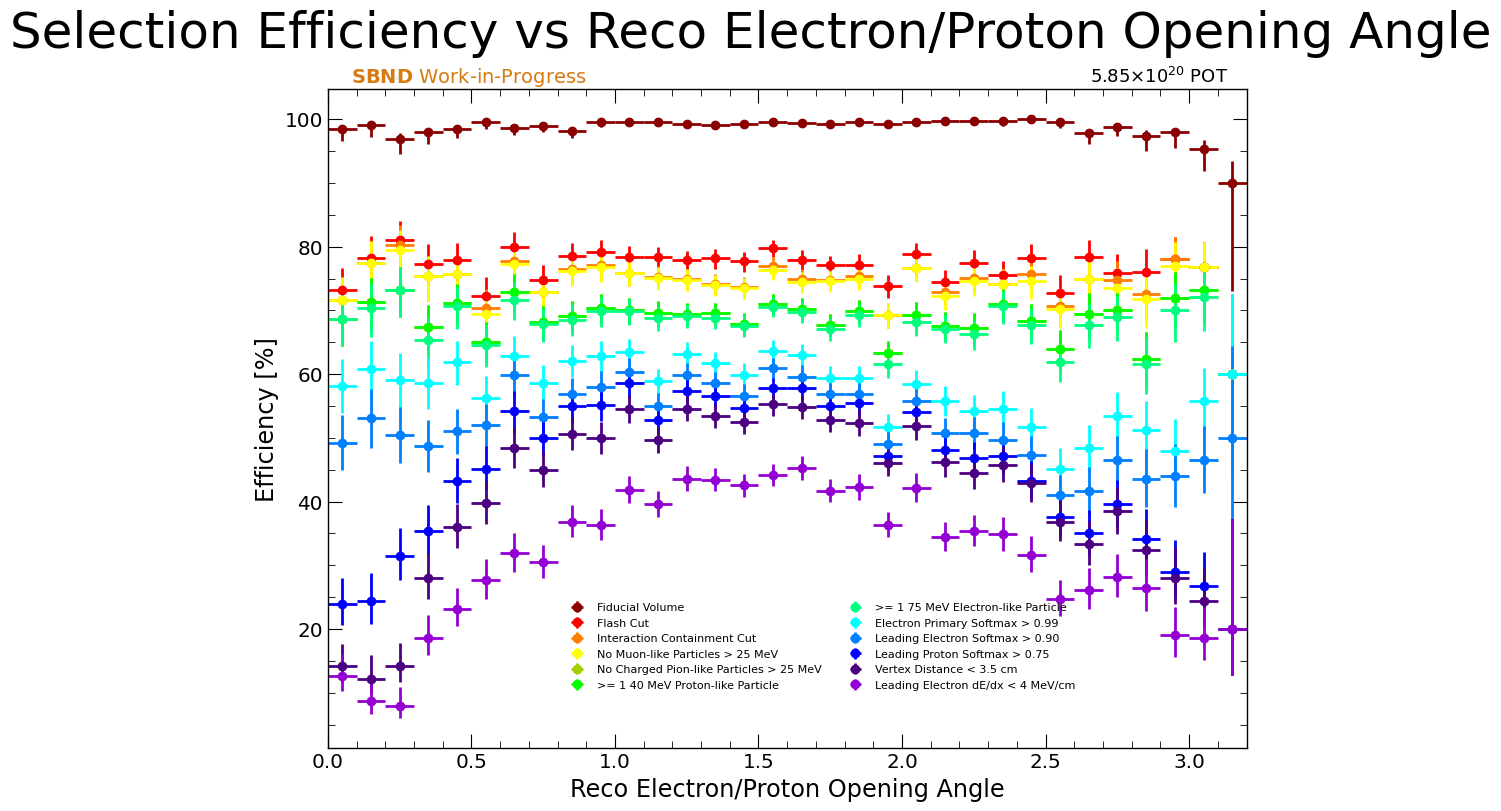

In [60]:
with open('/nashome/m/micarrig/sbnd/nueCCNp/plots/selection_efficiency_trueTree/efficiency_vs_recoElectronOpeningAngle.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)
    ax = eff_nuE.axes[0]
    legend = ax.get_legend()
    if legend is not None:
        legend_loc = legend._loc
        legend_bbox = legend.get_bbox_to_anchor()._bbox
        legend_frame = legend.get_frame_on()
        handles, labels = ax.get_legend_handles_labels()
        legend.remove()
        legend = ax.legend(handles, labels, ncol=2, fontsize=8, frameon=legend_frame, loc=legend_loc, bbox_to_anchor=legend_bbox)
        if legend.get_title() is not None:
            legend.get_title().set_fontsize(8)

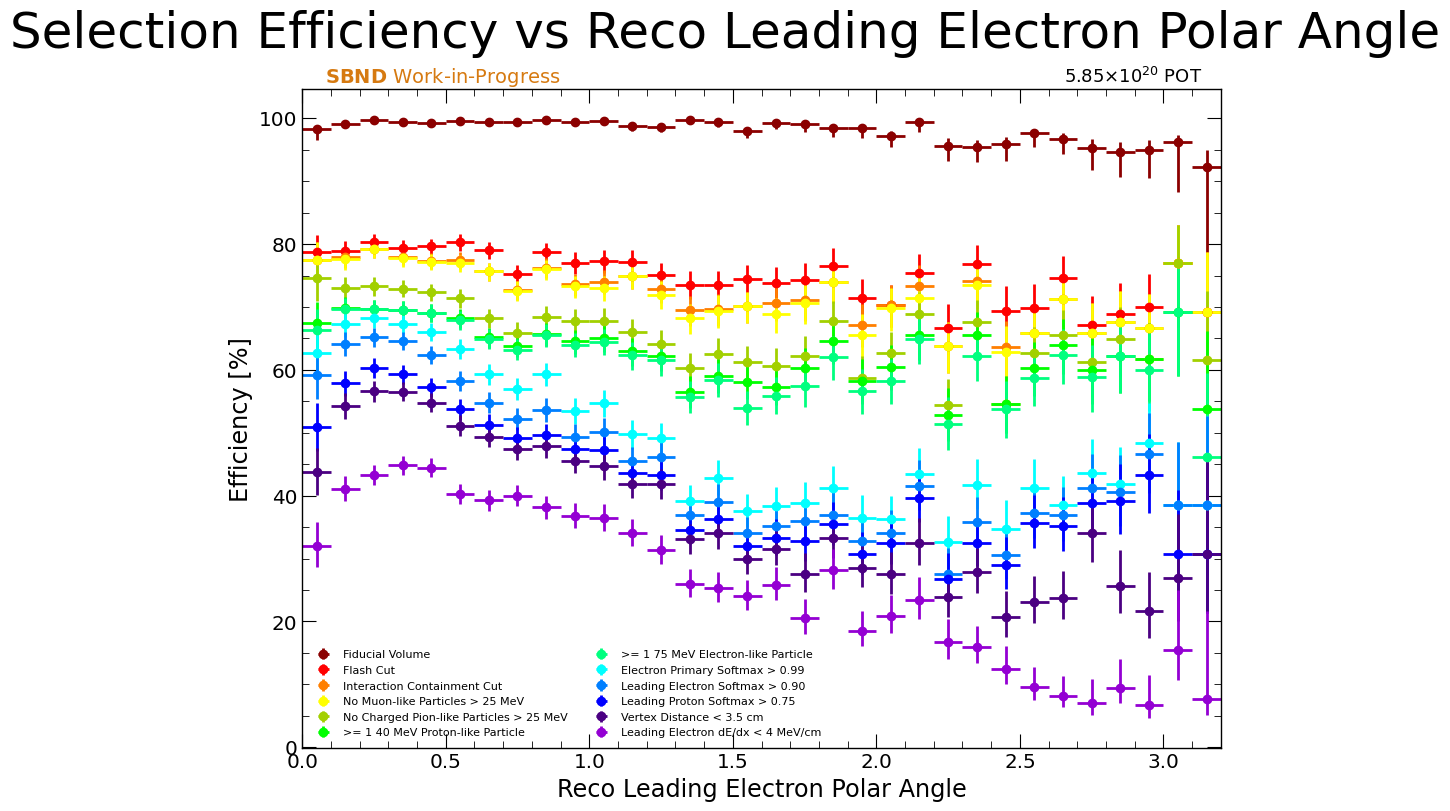

In [63]:
with open('/nashome/m/micarrig/sbnd/nueCCNp/plots/selection_efficiency_trueTree/efficiency_vs_recoElectronPolarAngle.pkl', 'rb') as f:
    eff_nuE = pickle.load(f)
    eff_nuE.set_size_inches(10, 8)
    ax = eff_nuE.axes[0]
    legend = ax.get_legend()
    if legend is not None:
        legend_loc = "lower left"
        legend_bbox = [0, 0]
        legend_frame = legend.get_frame_on()
        handles, labels = ax.get_legend_handles_labels()
        legend.remove()
        legend = ax.legend(handles, labels, ncol=2, fontsize=8, frameon=legend_frame, loc=legend_loc, bbox_to_anchor=legend_bbox)
        if legend.get_title() is not None:
            legend.get_title().set_fontsize(8)